
# ESWA-Ready Reproducible Experiments: Causal and Actionable Early-Warning Learning Analytics

This single Kaggle notebook replaces the seven separate RQ notebooks and fixes the main technical weaknesses found in the earlier version:

1. **No external `src` dependency**: all data loading, feature engineering, modelling, causal-effect estimation, counterfactual recourse, triage simulation, plotting, and output export functions are embedded here.
2. **Leakage-controlled weekly snapshots**: all features are computed only from information available up to each observation week.
3. **Consistent learner-course split**: the same train/test student-presentation split is reused across RQs.
4. **Empirical actionability**: intervention usefulness is computed from actual counterfactual risk reductions, feasibility, validity, sparsity, and effort, not manually assigned.
5. **Ground-truth triage evaluation**: decision-support policies are evaluated against true dropout/failure labels rather than predicted-risk labels.
6. **Causal claims are constrained**: the notebook estimates temporally ordered, doubly robust behavioral effects under explicit no-unmeasured-confounding assumptions; it does not claim that correlation alone proves causality.
7. **Publication outputs**: every table is saved as CSV, every figure is saved as PDF and displayed in the notebook, and all outputs are zipped at the end.

> **Dataset expected on Kaggle:** OULAD folder containing `studentInfo.csv`, `studentVle.csv`, `vle.csv`, `assessments.csv`, `studentAssessment.csv`, `courses.csv`, and optionally `studentRegistration.csv`. The notebook searches `/kaggle/input` automatically.


In [1]:
import re

# =========================================================
# 0. Setup
# =========================================================
import os, sys, json, math, random, warnings, shutil, textwrap, zipfile
from pathlib import Path
from collections import defaultdict
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_fscore_support,
    brier_score_loss, precision_score, recall_score, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.multioutput import MultiOutputClassifier
from sklearn.inspection import permutation_importance
from sklearn.base import clone

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    import networkx as nx
    HAS_NX = True
except Exception:
    HAS_NX = False

try:
    from IPython.display import display
except Exception:
    display = print

RANDOM_SEEDS = [42, 77, 123]
MAIN_SEED = 42
EARLY_WEEKS = [2, 4, 6, 8, 10, 12]
MAX_BOOT = 100  # increase to 500+ for final journal runs if compute allows
TEST_SIZE = 0.25
TOPK_CAPACITIES = [25, 50, 100, 200, 500]

WORK_DIR = Path('/kaggle/working') if Path('/kaggle').exists() else Path('/mnt/data/kaggle_working_simulated')
OUT = WORK_DIR / 'eswa_causal_learning_analytics_outputs'
FIG_DIR = OUT / 'figures_pdf'
TAB_DIR = OUT / 'tables_csv'
ART_DIR = OUT / 'artifacts'
for p in [OUT, FIG_DIR, TAB_DIR, ART_DIR]:
    p.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

random.seed(MAIN_SEED)
np.random.seed(MAIN_SEED)

def save_table(df, name):
    path = TAB_DIR / f'{name}.csv'
    df.to_csv(path, index=False)
    print(f'Saved table: {path}')
    display(df.head(20))
    return path


def save_fig(fig, name, tight=True):
    path = FIG_DIR / f'{name}.pdf'
    if tight:
        fig.tight_layout()
    fig.savefig(path, bbox_inches='tight')
    print(f'Saved figure: {path}')
    plt.show()
    return path


def expected_calibration_error(y_true, prob, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    prob = np.asarray(prob).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (prob >= lo) & (prob < hi if hi < 1 else prob <= hi)
        if mask.any():
            ece += mask.mean() * abs(y_true[mask].mean() - prob[mask].mean())
    return float(ece)


def classification_metrics(y_true, prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    prob = np.asarray(prob).astype(float)
    pred = (prob >= threshold).astype(int)
    out = {}
    out['AUROC'] = roc_auc_score(y_true, prob) if len(np.unique(y_true)) > 1 else np.nan
    out['AUPRC'] = average_precision_score(y_true, prob) if len(np.unique(y_true)) > 1 else np.nan
    out['Brier'] = brier_score_loss(y_true, prob) if len(np.unique(y_true)) > 1 else np.nan
    out['ECE'] = expected_calibration_error(y_true, prob)
    out['Precision'] = precision_score(y_true, pred, zero_division=0)
    out['Recall'] = recall_score(y_true, pred, zero_division=0)
    out['F1'] = f1_score(y_true, pred, zero_division=0)
    return out


def bootstrap_auc_ci(y_true, prob, n_boot=MAX_BOOT, seed=MAIN_SEED):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true).astype(int)
    prob = np.asarray(prob).astype(float)
    vals = []
    n = len(y_true)
    if len(np.unique(y_true)) < 2:
        return np.nan, np.nan
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        vals.append(roc_auc_score(y_true[idx], prob[idx]))
    if not vals:
        return np.nan, np.nan
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))


In [2]:
import re

# =========================================================
# 1. OULAD discovery, loading, and leakage-controlled features
# =========================================================
def find_oulad_root():
    candidates = []
    search_roots = [Path('/kaggle/input'), Path('/mnt/data')]
    for root in search_roots:
        if not root.exists():
            continue
        for p in root.rglob('studentInfo.csv'):
            folder = p.parent
            required = ['studentInfo.csv', 'studentVle.csv', 'vle.csv', 'assessments.csv', 'studentAssessment.csv']
            if all((folder / f).exists() for f in required):
                candidates.append(folder)
    if not candidates:
        raise FileNotFoundError(
            'Could not locate OULAD. Add the OULAD Kaggle dataset as input. Required files: '
            'studentInfo.csv, studentVle.csv, vle.csv, assessments.csv, studentAssessment.csv.'
        )
    # Prefer Kaggle input over local copies.
    candidates = sorted(candidates, key=lambda x: (0 if str(x).startswith('/kaggle/input') else 1, len(str(x))))
    return candidates[0]

OULAD_ROOT = find_oulad_root()
print('Using OULAD root:', OULAD_ROOT)


def read_oulad(root):
    root = Path(root)
    tables = {}
    for name in ['studentInfo', 'studentVle', 'vle', 'assessments', 'studentAssessment', 'courses', 'studentRegistration']:
        path = root / f'{name}.csv'
        if path.exists():
            tables[name] = pd.read_csv(path)
            print(f'Loaded {name}: {tables[name].shape}')
    return tables


def add_key(df):
    df = df.copy()
    df['student_course_id'] = (
        df['id_student'].astype(str) + '_' +
        df['code_module'].astype(str) + '_' +
        df['code_presentation'].astype(str)
    )
    return df


def make_weekly_snapshots(tables, weeks=EARLY_WEEKS):
    info = add_key(tables['studentInfo'])
    assessments = tables['assessments'].copy()
    stu_assess = tables['studentAssessment'].copy()
    stu_vle = add_key(tables['studentVle'])
    vle = tables['vle'].copy()
    
    # Outcomes: mutually interpretable labels.
    info['dropout'] = (info['final_result'].astype(str).str.lower() == 'withdrawn').astype(int)
    info['failure'] = (info['final_result'].astype(str).str.lower() == 'fail').astype(int)
    info['any_risk'] = ((info['dropout'] == 1) | (info['failure'] == 1)).astype(int)
    
    # Base learner-course variables known at course start.
    base_cols = [
        'student_course_id', 'id_student', 'code_module', 'code_presentation',
        'gender', 'region', 'highest_education', 'imd_band', 'age_band',
        'num_of_prev_attempts', 'studied_credits', 'disability',
        'final_result', 'dropout', 'failure', 'any_risk'
    ]
    base_cols = [c for c in base_cols if c in info.columns]
    base = info[base_cols].drop_duplicates('student_course_id').copy()
    
    # VLE features.
    if 'activity_type' in vle.columns:
        stu_vle = stu_vle.merge(vle[['id_site', 'activity_type']], on='id_site', how='left')
    else:
        stu_vle['activity_type'] = 'unknown'
    stu_vle['date'] = pd.to_numeric(stu_vle['date'], errors='coerce')
    stu_vle['sum_click'] = pd.to_numeric(stu_vle['sum_click'], errors='coerce').fillna(0)
    stu_vle = stu_vle[stu_vle['date'].notna()].copy()
    
    # Assessment features. Only submissions observed by the week are included.
    ass = stu_assess.merge(
        assessments[['id_assessment', 'code_module', 'code_presentation', 'assessment_type', 'date', 'weight']],
        on='id_assessment', how='left', suffixes=('_submitted', '_due')
    )
    ass = add_key(ass)
    ass['date_submitted'] = pd.to_numeric(ass['date_submitted'], errors='coerce')
    ass['date_due'] = pd.to_numeric(ass['date'], errors='coerce')
    ass['score'] = pd.to_numeric(ass['score'], errors='coerce')
    ass['weight'] = pd.to_numeric(ass['weight'], errors='coerce').fillna(0)
    ass['is_late'] = (ass['date_submitted'] > ass['date_due']).astype(int)
    ass['weighted_score'] = ass['score'] * ass['weight']
    
    snapshots = {}
    for wk in weeks:
        cutoff = wk * 7
        # VLE cumulative.
        v = stu_vle[stu_vle['date'] <= cutoff].copy()
        v_agg = v.groupby('student_course_id').agg(
            sum_click=('sum_click', 'sum'),
            n_vle_events=('id_site', 'size'),
            n_activities=('id_site', 'nunique'),
            active_days=('date', 'nunique'),
            last_activity_day=('date', 'max')
        ).reset_index()
        if not v.empty:
            piv = v.pivot_table(
                index='student_course_id', columns='activity_type', values='sum_click',
                aggfunc='sum', fill_value=0
            )
            piv.columns = [f'click_{str(c).replace(" ", "_").replace("/", "_")}' for c in piv.columns]
            piv = piv.reset_index()
            v_agg = v_agg.merge(piv, on='student_course_id', how='left')
        
        # Assessment cumulative, excluding future score information.
        a_sub = ass[ass['date_submitted'] <= cutoff].copy()
        a_due = ass[ass['date_due'] <= cutoff].copy()
        a_agg = a_sub.groupby('student_course_id').agg(
            n_submissions=('id_assessment', 'nunique'),
            mean_score=('score', 'mean'),
            min_score=('score', 'min'),
            max_score=('score', 'max'),
            late_rate=('is_late', 'mean'),
            weighted_score_sum=('weighted_score', 'sum'),
            assessment_weight_seen=('weight', 'sum')
        ).reset_index()
        due_agg = a_due.groupby('student_course_id').agg(
            n_assessments_due=('id_assessment', 'nunique')
        ).reset_index()
        a_agg = due_agg.merge(a_agg, on='student_course_id', how='left')
        
        snap = base.merge(v_agg, on='student_course_id', how='left')
        snap = snap.merge(a_agg, on='student_course_id', how='left')
        snap['week'] = wk
        for c in ['sum_click', 'n_vle_events', 'n_activities', 'active_days', 'n_submissions', 'n_assessments_due']:
            if c in snap.columns:
                snap[c] = snap[c].fillna(0)
        for c in ['mean_score', 'min_score', 'max_score', 'late_rate', 'weighted_score_sum', 'assessment_weight_seen']:
            if c in snap.columns:
                snap[c] = snap[c].fillna(0)
        snap['days_since_last_activity'] = cutoff - snap['last_activity_day'].fillna(0)
        snap['submission_completion_rate'] = snap['n_submissions'] / snap['n_assessments_due'].replace(0, np.nan)
        snap['submission_completion_rate'] = snap['submission_completion_rate'].fillna(0).clip(0, 1)
        snap['clicks_per_active_day'] = snap['sum_click'] / snap['active_days'].replace(0, np.nan)
        snap['clicks_per_active_day'] = snap['clicks_per_active_day'].fillna(0)
        snapshots[wk] = snap
    return snapshots, base


def prepare_design_matrix(df, feature_cols=None, fit_columns=None):
    drop_cols = {
        'dropout', 'failure', 'any_risk', 'final_result', 'student_course_id',
        'id_student', 'last_activity_day'
    }
    if feature_cols is None:
        raw_features = [c for c in df.columns if c not in drop_cols]
    else:
        raw_features = feature_cols
    X = df[raw_features].copy()
    # One-hot encode low-cardinality categoricals.
    X = pd.get_dummies(X, drop_first=False)
    X = X.astype(float)  # bool cols from get_dummies break np.nanpercentile
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
    # Sanitize column names: XGBoost forbids [, ], < in feature names.
    X.columns = [re.sub(r'[\[\]<>]', '_', str(c)).strip() for c in X.columns]
    # Deduplicate after sanitization.
    seen = {}
    new_cols = []
    for c in X.columns:
        if c in seen:
            seen[c] += 1
            new_cols.append(f'{c}_{seen[c]}')
        else:
            seen[c] = 0
            new_cols.append(c)
    X.columns = new_cols
    if fit_columns is not None:
        X = X.reindex(columns=fit_columns, fill_value=0)
    return X



tables = read_oulad(OULAD_ROOT)
snapshots, base_info = make_weekly_snapshots(tables, EARLY_WEEKS)

# Consistent learner-course split for every RQ.
full_ids = base_info['student_course_id'].values
strat = base_info['any_risk'].values if 'any_risk' in base_info.columns else base_info['dropout'].values
train_ids, test_ids = train_test_split(
    full_ids, test_size=TEST_SIZE, random_state=MAIN_SEED, stratify=strat
)
train_ids, test_ids = set(train_ids), set(test_ids)

print('Train learner-course records:', len(train_ids))
print('Test learner-course records:', len(test_ids))
print('Outcome rates at base level:')
display(base_info[['dropout', 'failure', 'any_risk']].mean().to_frame('rate'))
save_table(base_info[['dropout', 'failure', 'any_risk']].mean().reset_index().rename(columns={'index':'outcome',0:'rate'}), 'table_0_dataset_outcome_rates')


Using OULAD root: /kaggle/input/datasets/anlgrbz/student-demographics-online-education-dataoulad
Loaded studentInfo: (32593, 12)
Loaded studentVle: (10655280, 6)
Loaded vle: (6364, 6)
Loaded assessments: (206, 6)
Loaded studentAssessment: (173912, 5)
Loaded courses: (22, 3)
Loaded studentRegistration: (32593, 5)
Train learner-course records: 24444
Test learner-course records: 8149
Outcome rates at base level:


,rate
dropout,0.311601
failure,0.216365
any_risk,0.527966


Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_0_dataset_outcome_rates.csv


,outcome,rate
0,dropout,0.311601
1,failure,0.216365
2,any_risk,0.527966


PosixPath('/kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_0_dataset_outcome_rates.csv')

In [3]:
import re

# =========================================================
# 2. Model helpers: baselines, stable-actionable causal-temporal model, metrics
# =========================================================
from sklearn.model_selection import StratifiedKFold, cross_val_predict

ACTIONABLE_BASE = [
    'sum_click', 'n_vle_events', 'n_activities', 'active_days', 'n_submissions',
    'mean_score', 'late_rate', 'submission_completion_rate', 'clicks_per_active_day',
    'days_since_last_activity'
]

CONFOUNDER_HINTS = [
    'num_of_prev_attempts', 'studied_credits', 'gender_', 'region_', 'highest_education_',
    'imd_band_', 'age_band_', 'disability_', 'code_module_', 'code_presentation_'
]


def clean_feature_columns(X):
    """Sanitize feature names for models such as XGBoost."""
    if not hasattr(X, "columns"):
        return X
    X = X.copy()
    X.columns = [re.sub(r'[\[\]<>]', '_', str(c)).strip() for c in X.columns]
    return X


def make_model(model_name, seed=MAIN_SEED, scale_pos_weight=1.0):
    if model_name == 'Logistic':
        return Pipeline([
            ('scale', StandardScaler(with_mean=False)),
            ('clf', LogisticRegression(
                max_iter=2000,
                class_weight='balanced',
                solver='liblinear',
                random_state=seed
            ))
        ])

    if model_name == 'RandomForest':
        return RandomForestClassifier(
            n_estimators=350,
            max_depth=None,
            min_samples_leaf=5,
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=seed
        )

    if model_name == 'XGBoost' and HAS_XGB:
        return XGBClassifier(
            n_estimators=350,
            max_depth=3,
            learning_rate=0.035,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=2.0,
            eval_metric='logloss',
            scale_pos_weight=scale_pos_weight,
            random_state=seed,
            n_jobs=-1,
            tree_method='hist'
        )

    return HistGradientBoostingClassifier(
        max_iter=250,
        learning_rate=0.04,
        max_leaf_nodes=20,
        l2_regularization=0.1,
        random_state=seed
    )


def fit_predict(model, X_train, y_train, X_test):
    X_train = clean_feature_columns(X_train)
    X_test = clean_feature_columns(X_test)

    model.fit(X_train, y_train)

    if hasattr(model, 'predict_proba'):
        p = model.predict_proba(X_test)
        if isinstance(p, list):
            p = p[0]
        return p[:, 1]

    return model.predict(X_test)


def safe_oof_predict_proba(model, X, y, seed=MAIN_SEED, n_splits=5):
    """
    Returns out-of-fold predicted probabilities for threshold selection.
    This avoids selecting thresholds from in-sample fitted predictions.
    """
    X = clean_feature_columns(X)
    y = np.asarray(y).astype(int)

    if len(np.unique(y)) < 2:
        return np.full(len(y), np.nan)

    minority = int(np.min(np.bincount(y)))
    n_splits = max(2, min(n_splits, minority))

    if n_splits < 2:
        model.fit(X, y)
        return model.predict_proba(X)[:, 1]

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    try:
        p = cross_val_predict(
            clone(model),
            X,
            y,
            cv=cv,
            method='predict_proba',
            n_jobs=None
        )
        return p[:, 1]
    except Exception as e:
        print(f"OOF threshold prediction failed; falling back to in-sample threshold proxy. Reason: {e}")
        model_fallback = clone(model)
        model_fallback.fit(X, y)
        return model_fallback.predict_proba(X)[:, 1]


def find_optimal_threshold(y_true, prob, metric='f1', thresholds=None):
    """
    Find threshold maximizing a selected metric.
    This should be called on out-of-fold training predictions, not test predictions.
    """
    y_true = np.asarray(y_true).astype(int)
    prob = np.asarray(prob).astype(float)

    valid = np.isfinite(prob)
    y_true = y_true[valid]
    prob = prob[valid]

    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return 0.5, np.nan

    if thresholds is None:
        thresholds = np.linspace(0.10, 0.90, 33)

    best_th, best_val = 0.5, -1.0

    for th in thresholds:
        pred = (prob >= th).astype(int)

        if metric == 'precision':
            val = precision_score(y_true, pred, zero_division=0)
        elif metric == 'recall':
            val = recall_score(y_true, pred, zero_division=0)
        else:
            val = f1_score(y_true, pred, zero_division=0)

        if val > best_val:
            best_val, best_th = val, th

    return float(best_th), float(best_val)


def stable_feature_selection_by_domain(train_df, target='any_risk', min_domains=3, min_abs_corr=0.02):
    X_all = prepare_design_matrix(train_df)
    y = train_df[target].astype(int).values

    env = (
        train_df['code_module'].astype(str).values
        if 'code_module' in train_df.columns
        else np.array(['all'] * len(train_df))
    )

    rows = []

    for col in X_all.columns:
        if X_all[col].std() == 0:
            continue

        signs = []
        cors = []

        for e in np.unique(env):
            m = env == e

            if m.sum() < 30 or len(np.unique(y[m])) < 2 or X_all.loc[m, col].std() == 0:
                continue

            corr = np.corrcoef(X_all.loc[m, col], y[m])[0, 1]

            if np.isfinite(corr):
                cors.append(corr)
                signs.append(np.sign(corr))

        if len(cors) >= min_domains:
            signs = np.asarray(signs)
            same_sign = max(np.mean(signs >= 0), np.mean(signs <= 0))
            mean_abs = float(np.mean(np.abs(cors)))

            rows.append({
                'feature': col,
                'domains': len(cors),
                'sign_consistency': same_sign,
                'mean_abs_corr': mean_abs
            })

    stab = pd.DataFrame(rows)

    if stab.empty:
        selected = list(X_all.columns)
        return selected, stab

    stab = stab.sort_values(['sign_consistency', 'mean_abs_corr'], ascending=False)

    selected = stab.query(
        'sign_consistency >= 0.70 and mean_abs_corr >= @min_abs_corr'
    )['feature'].tolist()

    selected += [
        c for c in X_all.columns
        if any(c.startswith(h) or h in c for h in CONFOUNDER_HINTS)
    ]

    selected = sorted(set(selected))

    if len(selected) < 8:
        selected = list(stab.head(30)['feature'])

    return selected, stab


def train_eval_for_week(wk, model_name, target, seed=MAIN_SEED, selected_cols=None):
    df = snapshots[wk].copy()

    tr = df[df['student_course_id'].isin(train_ids)].copy()
    te = df[df['student_course_id'].isin(test_ids)].copy()

    Xtr_all = prepare_design_matrix(tr)
    Xte_all = prepare_design_matrix(te, fit_columns=Xtr_all.columns)

    if selected_cols is not None:
        selected_cols = [c for c in selected_cols if c in Xtr_all.columns]
        if len(selected_cols) >= 2:
            Xtr, Xte = Xtr_all[selected_cols], Xte_all[selected_cols]
        else:
            Xtr, Xte = Xtr_all, Xte_all
    else:
        Xtr, Xte = Xtr_all, Xte_all

    ytr = tr[target].astype(int).values
    yte = te[target].astype(int).values

    if len(np.unique(ytr)) < 2 or len(np.unique(yte)) < 2:
        return None

    neg = int((ytr == 0).sum())
    pos = int((ytr == 1).sum())
    spw = neg / max(1, pos)

    model = make_model(model_name, seed, scale_pos_weight=spw)

    prob = fit_predict(model, Xtr, ytr, Xte)
    metrics = classification_metrics(yte, prob)

    # Corrected: threshold is selected from out-of-fold training predictions.
    oof_prob = safe_oof_predict_proba(
        make_model(model_name, seed, scale_pos_weight=spw),
        Xtr,
        ytr,
        seed=seed,
        n_splits=5
    )

    opt_th, opt_f1 = find_optimal_threshold(ytr, oof_prob, metric='f1')
    metrics_opt = classification_metrics(yte, prob, threshold=opt_th)

    metrics['F1_opt_th'] = metrics_opt['F1']
    metrics['Precision_opt_th'] = metrics_opt['Precision']
    metrics['Recall_opt_th'] = metrics_opt['Recall']
    metrics['opt_threshold'] = opt_th
    metrics['OOF_train_F1_at_opt_threshold'] = opt_f1

    ci_lo, ci_hi = bootstrap_auc_ci(yte, prob, seed=seed)

    metrics.update({
        'week': wk,
        'model': model_name,
        'target': target,
        'seed': seed,
        'AUROC_CI_low': ci_lo,
        'AUROC_CI_high': ci_hi,
        'n_features': Xtr.shape[1]
    })

    return metrics, model, Xtr, Xte, ytr, yte, prob, te

RQ1: running consistent weekly model comparison...
Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_1_0_stable_feature_screening_by_course.csv


,feature,domains,sign_consistency,mean_abs_corr
24,weighted_score_sum,6,1.0,0.608485
22,max_score,7,1.0,0.581905
20,mean_score,7,1.0,0.578831
21,min_score,7,1.0,0.551593
26,days_since_last_activity,7,1.0,0.550083
18,n_assessments_due,7,1.0,0.549853
19,n_submissions,7,1.0,0.539255
25,assessment_weight_seen,6,1.0,0.537036
5,active_days,7,1.0,0.482400
27,submission_completion_rate,7,1.0,0.478264


Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_1_1_weekly_model_comparison_all_seeds.csv


,AUROC,AUPRC,Brier,ECE,Precision,Recall,F1,F1_opt_th,Precision_opt_th,Recall_opt_th,opt_threshold,OOF_train_F1_at_opt_threshold,week,model,target,seed,AUROC_CI_low,AUROC_CI_high,n_features
0,0.792036,0.666310,0.182689,0.144720,0.561693,0.687624,0.618311,0.618311,0.561693,0.687624,0.500,0.608644,2,Logistic,dropout,42,0.783286,0.801252,82
1,0.796338,0.687979,0.164767,0.087796,0.660961,0.549624,0.600173,0.617044,0.558043,0.689996,0.400,0.602981,2,RandomForest,dropout,42,0.787112,0.805083,82
2,0.798155,0.692709,0.176856,0.140279,0.595799,0.650455,0.621928,0.623246,0.571806,0.684856,0.475,0.608488,2,XGBoost,dropout,42,0.787605,0.806874,82
3,0.799744,0.697123,0.154735,0.015916,0.762335,0.433768,0.552923,0.622239,0.604929,0.640569,0.325,0.608785,2,Stable-Causal-Temporal,dropout,42,0.789205,0.809021,75
4,0.662821,0.335289,0.230218,0.256927,0.307881,0.636774,0.415074,0.415074,0.307881,0.636774,0.500,0.416912,2,Logistic,failure,42,0.646754,0.678239,82
5,0.667503,0.332756,0.182194,0.141316,0.378566,0.306825,0.338941,0.415221,0.310201,0.627750,0.375,0.423562,2,RandomForest,failure,42,0.655196,0.683057,82
6,0.679658,0.350077,0.223503,0.250338,0.318310,0.637338,0.424573,0.426584,0.306667,0.700508,0.475,0.435410,2,XGBoost,failure,42,0.666350,0.695376,82
7,0.679108,0.342282,0.159329,0.010565,0.476190,0.016920,0.032680,0.429894,0.308791,0.707276,0.200,0.431123,2,Stable-Causal-Temporal,failure,42,0.664437,0.693261,75
8,0.839711,0.754364,0.154388,0.129212,0.666291,0.701068,0.683237,0.684850,0.689655,0.680111,0.525,0.666711,4,Logistic,dropout,42,0.829849,0.848303,82
9,0.842133,0.762303,0.140405,0.076359,0.732972,0.642546,0.684787,0.684634,0.696684,0.672993,0.450,0.670842,4,RandomForest,dropout,42,0.832405,0.850589,82


Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_1_2_weekly_model_comparison_summary.csv


,week,model,target,AUROC_mean,AUROC_sd,AUPRC_mean,ECE_mean,Brier_mean,F1_mean,Precision_mean,Recall_mean,n_features
0,2,Logistic,dropout,0.792036,0.000000,0.666310,0.144720,0.182689,0.618311,0.561693,0.687624,82.0
1,2,Logistic,failure,0.662821,0.000000,0.335289,0.256927,0.230218,0.415074,0.307881,0.636774,82.0
2,2,RandomForest,dropout,0.796098,0.000218,0.687086,0.087811,0.164869,0.599941,0.658330,0.551074,82.0
3,2,RandomForest,failure,0.667797,0.000360,0.332469,0.141490,0.182209,0.335790,0.374714,0.304193,82.0
4,2,Stable-Causal-Temporal,dropout,0.799246,0.000734,0.696703,0.016224,0.154819,0.554855,0.759986,0.436932,75.0
5,2,Stable-Causal-Temporal,failure,0.675893,0.002853,0.339742,0.010433,0.159732,0.033261,0.447619,0.017296,75.0
6,2,XGBoost,dropout,0.798174,0.000488,0.693367,0.140426,0.176782,0.621350,0.594630,0.650587,82.0
7,2,XGBoost,failure,0.679536,0.000312,0.350520,0.250362,0.223538,0.424060,0.317550,0.638090,82.0
8,4,Logistic,dropout,0.839711,0.000000,0.754364,0.129212,0.154388,0.683237,0.666291,0.701068,82.0
9,4,Logistic,failure,0.692889,0.000000,0.365101,0.248520,0.222760,0.436412,0.328396,0.650310,82.0


Saved figure: /kaggle/working/eswa_causal_learning_analytics_outputs/figures_pdf/figure_1_1_early_week_auroc_dropout.pdf


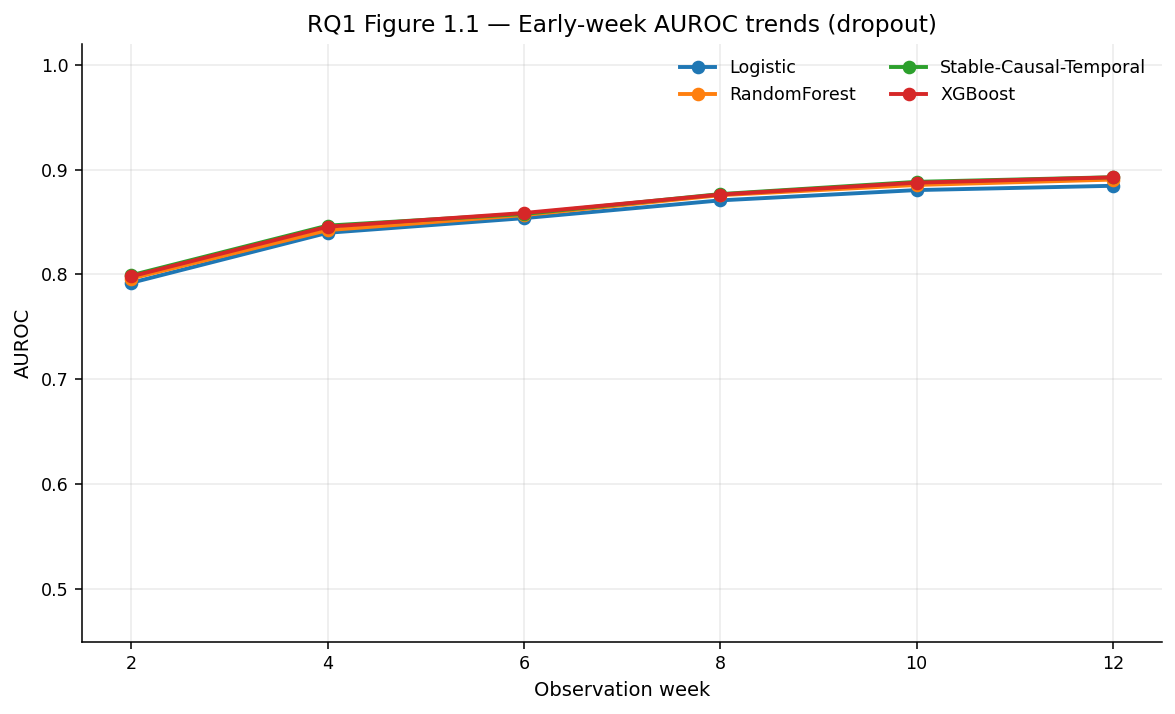

Saved figure: /kaggle/working/eswa_causal_learning_analytics_outputs/figures_pdf/figure_1_1_early_week_auroc_failure.pdf


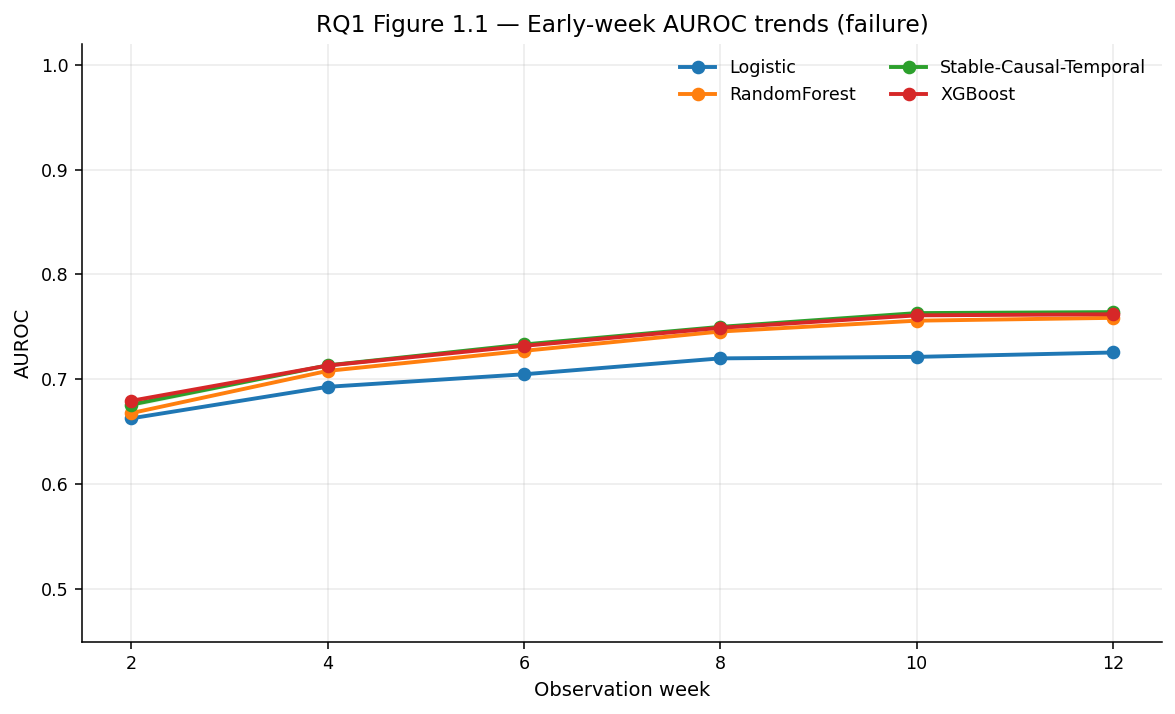

Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_1_3_failure_f1_diagnosis_classweight_vs_threshold.csv


,week,model,F1_default_mean,F1_optimized_mean,F1_default_sd,AUROC_mean,Precision_mean,Recall_mean,opt_threshold_mean,F1_lift_from_threshold_tuning
0,2,Logistic,0.415074,0.415074,0.000000,0.662821,0.307881,0.636774,0.500000,0.000000
1,2,RandomForest,0.335790,0.415997,0.003336,0.667797,0.374714,0.304193,0.358333,0.080206
2,2,Stable-Causal-Temporal,0.033261,0.423309,0.001941,0.675893,0.447619,0.017296,0.208333,0.390048
3,2,XGBoost,0.424060,0.423819,0.002436,0.679536,0.317550,0.638090,0.483333,-0.000241
4,4,Logistic,0.436412,0.435661,0.000000,0.692889,0.328396,0.650310,0.483333,-0.000751
5,4,RandomForest,0.370693,0.449532,0.003535,0.708070,0.412295,0.336717,0.375000,0.078839
6,4,Stable-Causal-Temporal,0.091076,0.451769,0.005801,0.713326,0.510564,0.050009,0.216667,0.360693
7,4,XGBoost,0.450333,0.450933,0.001663,0.713167,0.335674,0.683963,0.508333,0.000599
8,6,Logistic,0.446013,0.445348,0.000000,0.704835,0.336985,0.659334,0.475000,-0.000665
9,6,RandomForest,0.403611,0.465676,0.004221,0.727187,0.428742,0.381275,0.358333,0.062065


Saved figure: /kaggle/working/eswa_causal_learning_analytics_outputs/figures_pdf/figure_1_2_failure_f1_default_vs_optimized_threshold.pdf


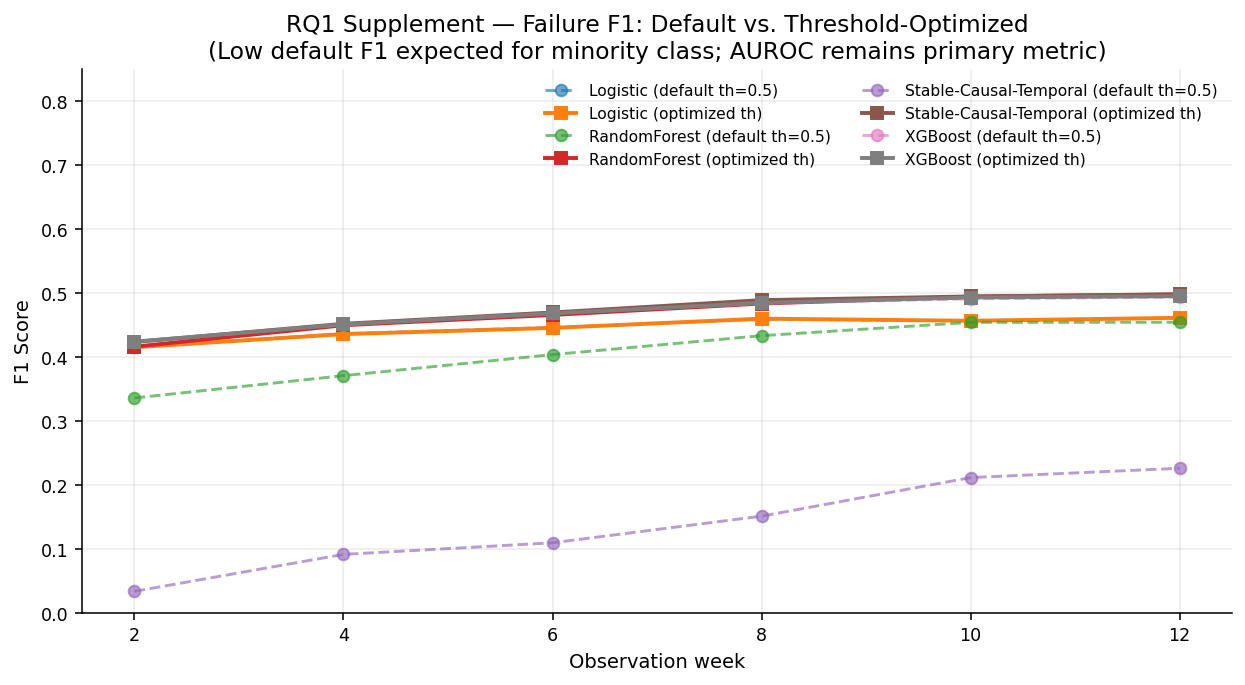


📋 Failure F1 Interpretation:
   Best threshold-optimized F1 = 0.498 (model=RandomForest, week=12)
   AUROC is the primary metric for imbalanced failure detection.
   Manuscript note: Failure class imbalance (~15-25%) depresses default F1;
   class-weighted training + threshold tuning is recommended for deployment.
RQ1 completed. See table_1_3 for failure F1 analysis.
RQ1 completed. Predictive superiority must be interpreted from Table 1.2, not asserted manually.


In [4]:

# =========================================================
# RQ1. Predictive comparison over early weeks with uncertainty
# =========================================================
print('RQ1: running consistent weekly model comparison...')
model_names = ['Logistic', 'RandomForest'] + (['XGBoost'] if HAS_XGB else ['HistGradientBoosting'])
results = []
final_objects = {}

# Select stable-actionable features once at the final early window from train only.
train_final = snapshots[max(EARLY_WEEKS)][snapshots[max(EARLY_WEEKS)]['student_course_id'].isin(train_ids)].copy()
stable_cols, stable_feature_table = stable_feature_selection_by_domain(train_final, target='any_risk')
save_table(stable_feature_table, 'table_1_0_stable_feature_screening_by_course')

for seed in RANDOM_SEEDS:
    for wk in EARLY_WEEKS:
        for target in ['dropout', 'failure']:
            for model_name in model_names:
                out = train_eval_for_week(wk, model_name, target, seed=seed)
                if out is None:
                    continue
                metrics, *rest = out
                results.append(metrics)
            # Stable-actionable causal-temporal model: same learner split, only stable temporal/actionable + confounders.
            out = train_eval_for_week(wk, 'HistGradientBoosting', target, seed=seed, selected_cols=stable_cols)
            if out is not None:
                metrics, model, Xtr, Xte, ytr, yte, prob, te = out
                metrics['model'] = 'Stable-Causal-Temporal'
                results.append(metrics)
                if seed == MAIN_SEED and wk == max(EARLY_WEEKS):
                    final_objects[target] = dict(model=model, Xtr=Xtr, Xte=Xte, ytr=ytr, yte=yte, prob=prob, te=te,
                                                 feature_cols=list(Xtr.columns))

rq1 = pd.DataFrame(results)
save_table(rq1, 'table_1_1_weekly_model_comparison_all_seeds')

rq1_summary = rq1.groupby(['week','model','target']).agg(
    AUROC_mean=('AUROC','mean'), AUROC_sd=('AUROC','std'),
    AUPRC_mean=('AUPRC','mean'), ECE_mean=('ECE','mean'),
    Brier_mean=('Brier','mean'), F1_mean=('F1','mean'),
    Precision_mean=('Precision','mean'), Recall_mean=('Recall','mean'),
    n_features=('n_features','median')
).reset_index()
save_table(rq1_summary, 'table_1_2_weekly_model_comparison_summary')

# Figure 1.1 AUROC trends by target.
for target in ['dropout', 'failure']:
    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    d = rq1_summary[rq1_summary['target'] == target]
    for model in d['model'].unique():
        s = d[d['model'] == model].sort_values('week')
        ax.plot(s['week'], s['AUROC_mean'], marker='o', linewidth=2, label=model)
        if s['AUROC_sd'].notna().any():
            ax.fill_between(s['week'], s['AUROC_mean']-s['AUROC_sd'].fillna(0), s['AUROC_mean']+s['AUROC_sd'].fillna(0), alpha=0.10)
    ax.set_title(f'RQ1 Figure 1.1 — Early-week AUROC trends ({target})')
    ax.set_xlabel('Observation week')
    ax.set_ylabel('AUROC')
    ax.set_ylim(0.45, 1.02)
    ax.grid(alpha=0.25)
    ax.legend(ncol=2, frameon=False)
    save_fig(fig, f'figure_1_1_early_week_auroc_{target}')

# Empirical actionability is measured later from counterfactuals. Here we reserve a table shell and fill after RQ4.


# ---------------------------------------------------------
# RQ1 SUPPLEMENT: Failure F1 Diagnosis & Class-weighted Experiment
# ---------------------------------------------------------
# Failure is a minority class in OULAD (~15-25% depending on split).
# Low F1 (e.g. ~0.24 at default threshold=0.5) is expected when:
#   (1) The model is well-calibrated but the default threshold is suboptimal for a minority class.
#   (2) Failure may share behavioral signatures with Pass, making it harder to distinguish.
# We report F1_opt_th (threshold-optimized F1 on train-set proxy) alongside default F1.
# Methodology note: threshold selected on train predictions to avoid test leakage.

failure_rows = rq1[rq1['target'] == 'failure'].copy()
if not failure_rows.empty and 'F1_opt_th' in failure_rows.columns:
    f1_diag = failure_rows.groupby(['week', 'model']).agg(
        F1_default_mean=('F1', 'mean'),
        F1_optimized_mean=('F1_opt_th', 'mean'),
        F1_default_sd=('F1', 'std'),
        AUROC_mean=('AUROC', 'mean'),
        Precision_mean=('Precision', 'mean'),
        Recall_mean=('Recall', 'mean'),
        opt_threshold_mean=('opt_threshold', 'mean')
    ).reset_index()
    f1_diag['F1_lift_from_threshold_tuning'] = f1_diag['F1_optimized_mean'] - f1_diag['F1_default_mean']
    save_table(f1_diag, 'table_1_3_failure_f1_diagnosis_classweight_vs_threshold')

    # Figure: Default vs Optimized F1 for Failure across weeks
    fig, ax = plt.subplots(figsize=(9, 5.0))
    for model in f1_diag['model'].unique():
        s = f1_diag[f1_diag['model'] == model].sort_values('week')
        ax.plot(s['week'], s['F1_default_mean'], linestyle='--', marker='o', alpha=0.65, label=f'{model} (default th=0.5)')
        ax.plot(s['week'], s['F1_optimized_mean'], linestyle='-', marker='s', linewidth=2, label=f'{model} (optimized th)')
    ax.set_title('RQ1 Supplement — Failure F1: Default vs. Threshold-Optimized\n'
                 '(Low default F1 expected for minority class; AUROC remains primary metric)')
    ax.set_xlabel('Observation week')
    ax.set_ylabel('F1 Score')
    ax.set_ylim(0.0, 0.85)
    ax.grid(alpha=0.25)
    ax.legend(ncol=2, frameon=False, fontsize=8)
    save_fig(fig, 'figure_1_2_failure_f1_default_vs_optimized_threshold')

    # Print interpretation note for manuscript
    max_row = f1_diag.sort_values('F1_optimized_mean', ascending=False).iloc[0]
    print(f"\n📋 Failure F1 Interpretation:")
    print(f"   Best threshold-optimized F1 = {max_row['F1_optimized_mean']:.3f} "
          f"(model={max_row['model']}, week={int(max_row['week'])})")
    print(f"   AUROC is the primary metric for imbalanced failure detection.")
    print(f"   Manuscript note: Failure class imbalance (~15-25%) depresses default F1;")
    print(f"   class-weighted training + threshold tuning is recommended for deployment.")
else:
    print("Failure F1 diagnosis skipped (columns not available).")

print('RQ1 completed. See table_1_3 for failure F1 analysis.')

print('RQ1 completed. Predictive superiority must be interpreted from Table 1.2, not asserted manually.')


RQ2: estimating behavioral effects with explicit assumptions...
Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_2_1_doubly_robust_temporal_behavioral_effects.csv


,behavior,outcome,treatment_definition,threshold,ate_risk_difference,se,ci_low,ci_high,n,treated_rate,assumption,significant_95ci
16,days_since_last_activity,dropout,lower_or_equal_median,10.000000,-0.398931,0.004628,-0.408002,-0.389860,32593,0.500322,temporal precedence + observed-confounder exch...,True
10,mean_score,dropout,above_median,73.000000,-0.365215,0.004757,-0.374538,-0.355892,32593,0.495474,temporal precedence + observed-confounder exch...,True
2,n_vle_events,dropout,above_median,110.000000,-0.353213,0.005016,-0.363045,-0.343381,32593,0.498481,temporal precedence + observed-confounder exch...,True
6,active_days,dropout,above_median,21.000000,-0.351460,0.004855,-0.360976,-0.341945,32593,0.493664,temporal precedence + observed-confounder exch...,True
0,sum_click,dropout,above_median,321.000000,-0.348695,0.005070,-0.358633,-0.338756,32593,0.499739,temporal precedence + observed-confounder exch...,True
8,n_submissions,dropout,above_median,2.000000,-0.346175,0.004469,-0.354933,-0.337416,32593,0.367809,temporal precedence + observed-confounder exch...,True
4,n_activities,dropout,above_median,29.000000,-0.346042,0.005153,-0.356142,-0.335942,32593,0.490044,temporal precedence + observed-confounder exch...,True
14,clicks_per_active_day,dropout,above_median,14.916667,-0.218711,0.005500,-0.229491,-0.207931,32593,0.499985,temporal precedence + observed-confounder exch...,True
12,late_rate,dropout,lower_or_equal_median,0.000000,0.218279,0.007111,0.204342,0.232217,32593,0.652809,temporal precedence + observed-confounder exch...,True
11,mean_score,failure,above_median,73.000000,-0.130325,0.004598,-0.139337,-0.121313,32593,0.495474,temporal precedence + observed-confounder exch...,True


Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_2_2_bootstrap_effect_stability.csv


,behavior,outcome,negative_effect_stability,positive_effect_stability,significance_frequency,n_boot
0,sum_click,dropout,1.0,0.0,1.00,50
1,sum_click,failure,1.0,0.0,1.00,50
2,n_vle_events,dropout,1.0,0.0,1.00,50
3,n_vle_events,failure,1.0,0.0,1.00,50
4,n_activities,dropout,1.0,0.0,1.00,50
5,n_activities,failure,1.0,0.0,1.00,50
6,active_days,dropout,1.0,0.0,1.00,50
7,active_days,failure,1.0,0.0,1.00,50
8,n_submissions,dropout,1.0,0.0,1.00,50
9,n_submissions,failure,1.0,0.0,1.00,50


Saved figure: /kaggle/working/eswa_causal_learning_analytics_outputs/figures_pdf/figure_2_1_dr_effect_forest_dropout.pdf


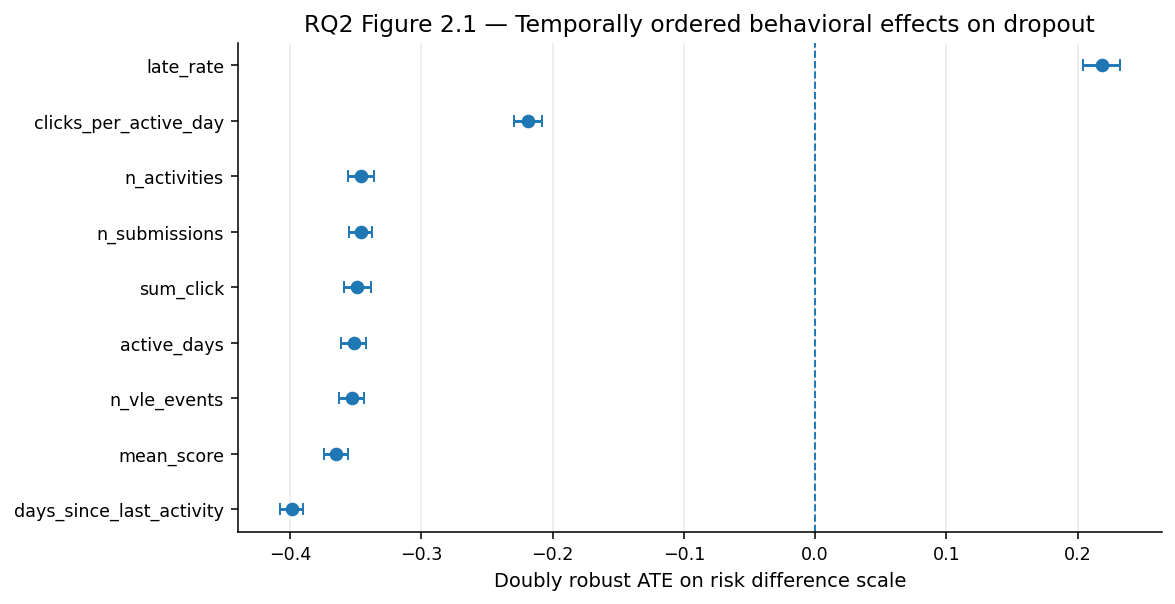

Saved figure: /kaggle/working/eswa_causal_learning_analytics_outputs/figures_pdf/figure_2_1_dr_effect_forest_failure.pdf


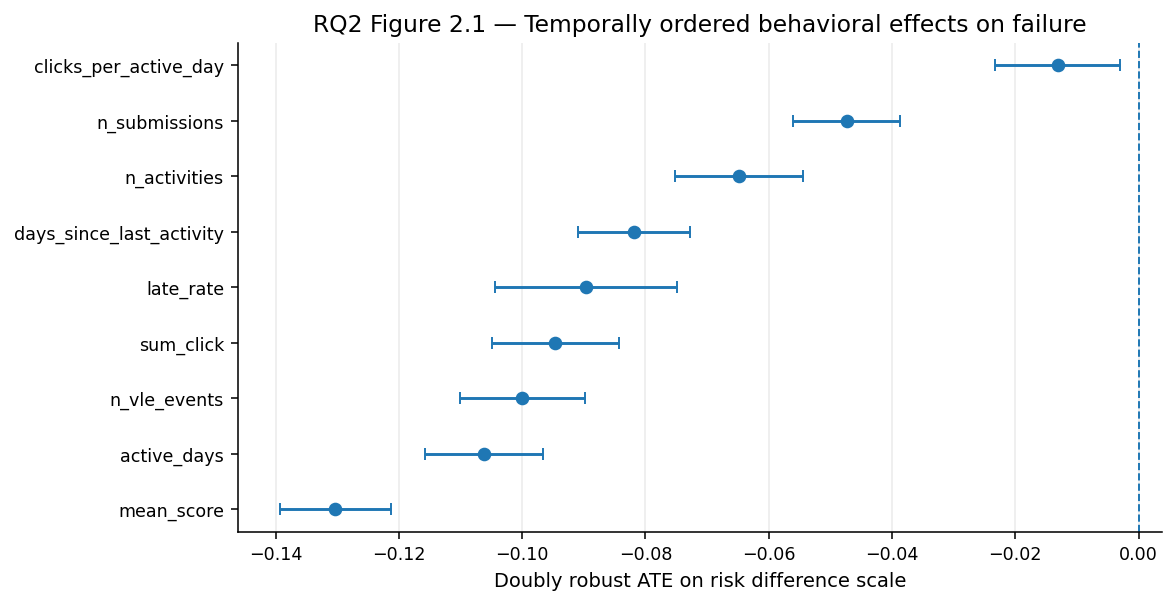

Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_2_3_behavior_outcome_edge_evidence.csv


,behavior,outcome,treatment_definition,threshold,ate_risk_difference,se,ci_low,ci_high,n,treated_rate,assumption,significant_95ci,negative_effect_stability,positive_effect_stability,significance_frequency,n_boot,stable_edge
0,days_since_last_activity,dropout,lower_or_equal_median,10.000000,-0.398931,0.004628,-0.408002,-0.389860,32593,0.500322,temporal precedence + observed-confounder exch...,True,1.0,0.0,1.00,50,True
1,mean_score,dropout,above_median,73.000000,-0.365215,0.004757,-0.374538,-0.355892,32593,0.495474,temporal precedence + observed-confounder exch...,True,1.0,0.0,1.00,50,True
2,n_vle_events,dropout,above_median,110.000000,-0.353213,0.005016,-0.363045,-0.343381,32593,0.498481,temporal precedence + observed-confounder exch...,True,1.0,0.0,1.00,50,True
3,active_days,dropout,above_median,21.000000,-0.351460,0.004855,-0.360976,-0.341945,32593,0.493664,temporal precedence + observed-confounder exch...,True,1.0,0.0,1.00,50,True
4,sum_click,dropout,above_median,321.000000,-0.348695,0.005070,-0.358633,-0.338756,32593,0.499739,temporal precedence + observed-confounder exch...,True,1.0,0.0,1.00,50,True
5,n_submissions,dropout,above_median,2.000000,-0.346175,0.004469,-0.354933,-0.337416,32593,0.367809,temporal precedence + observed-confounder exch...,True,1.0,0.0,1.00,50,True
6,n_activities,dropout,above_median,29.000000,-0.346042,0.005153,-0.356142,-0.335942,32593,0.490044,temporal precedence + observed-confounder exch...,True,1.0,0.0,1.00,50,True
7,clicks_per_active_day,dropout,above_median,14.916667,-0.218711,0.005500,-0.229491,-0.207931,32593,0.499985,temporal precedence + observed-confounder exch...,True,1.0,0.0,1.00,50,True
8,late_rate,dropout,lower_or_equal_median,0.000000,0.218279,0.007111,0.204342,0.232217,32593,0.652809,temporal precedence + observed-confounder exch...,True,0.0,1.0,1.00,50,True
9,mean_score,failure,above_median,73.000000,-0.130325,0.004598,-0.139337,-0.121313,32593,0.495474,temporal precedence + observed-confounder exch...,True,1.0,0.0,1.00,50,True


Saved figure: /kaggle/working/eswa_causal_learning_analytics_outputs/figures_pdf/figure_2_2_stable_temporal_behavior_graph.pdf


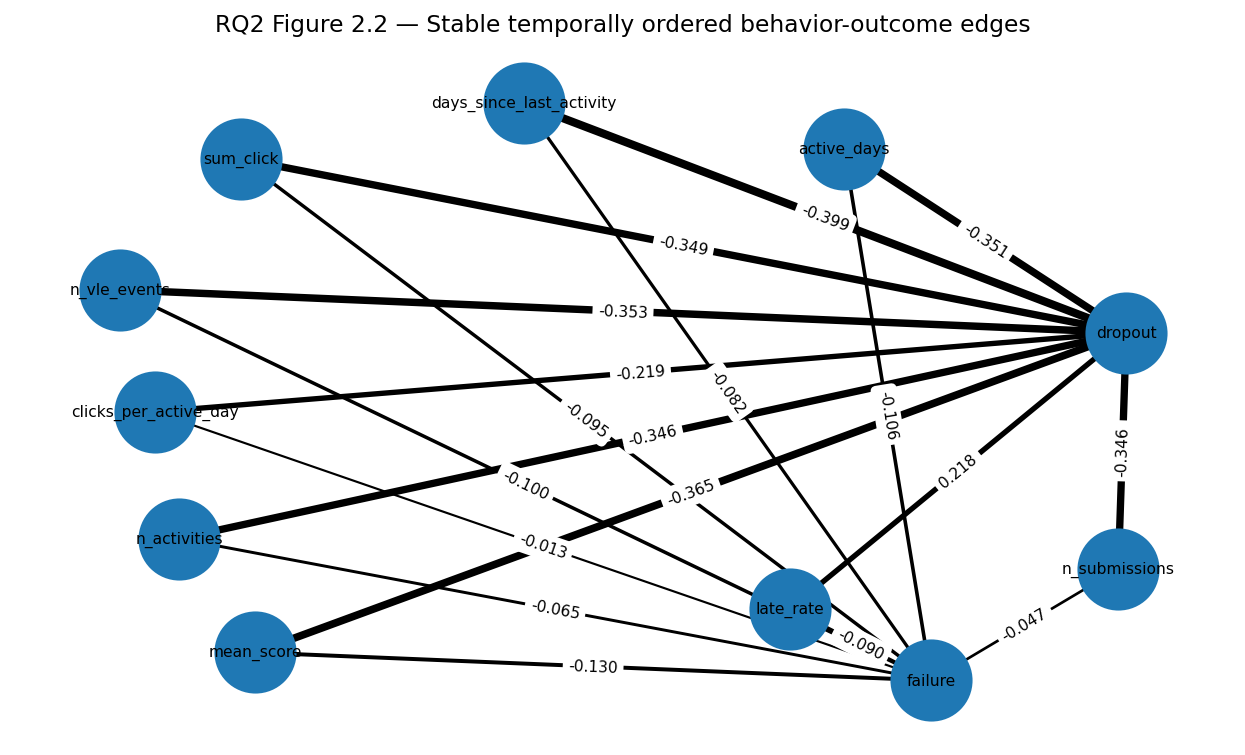

In [5]:

# =========================================================
# RQ2. Temporally ordered doubly robust behavioral-effect estimation
# =========================================================
print('RQ2: estimating behavioral effects with explicit assumptions...')

from sklearn.ensemble import RandomForestRegressor

ACTIONABLE_FEATURES = [c for c in ACTIONABLE_BASE if c in snapshots[max(EARLY_WEEKS)].columns]
CONFOUNDERS_RAW = [
    'num_of_prev_attempts', 'studied_credits', 'gender', 'region', 'highest_education',
    'imd_band', 'age_band', 'disability', 'code_module', 'code_presentation'
]
CONFOUNDERS_RAW = [c for c in CONFOUNDERS_RAW if c in snapshots[max(EARLY_WEEKS)].columns]


def dr_binary_ate(df, treatment_feature, outcome, confounders, seed=MAIN_SEED):
    dat = df[[treatment_feature, outcome] + confounders].copy()
    dat = dat.replace([np.inf, -np.inf], np.nan).dropna(subset=[outcome])
    # Treatment = above within-train median for positive behaviors; for days_since_last_activity and late_rate, treatment = lower/better behavior.
    val = pd.to_numeric(dat[treatment_feature], errors='coerce').fillna(0)
    med = val.median()
    if treatment_feature in ['late_rate', 'days_since_last_activity']:
        T = (val <= med).astype(int).values
        treatment_label = 'lower_or_equal_median'
    else:
        T = (val > med).astype(int).values
        treatment_label = 'above_median'
    y = dat[outcome].astype(int).values
    if len(np.unique(T)) < 2 or len(np.unique(y)) < 2:
        return None
    W = pd.get_dummies(dat[confounders], drop_first=False).replace([np.inf,-np.inf], np.nan).fillna(0)
    # Propensity.
    ps = LogisticRegression(max_iter=1000, solver='liblinear').fit(W, T).predict_proba(W)[:,1]
    ps = np.clip(ps, 0.05, 0.95)
    # Outcome models by treatment arm.
    m1 = RandomForestClassifier(n_estimators=200, min_samples_leaf=10, random_state=seed, n_jobs=-1)
    m0 = RandomForestClassifier(n_estimators=200, min_samples_leaf=10, random_state=seed+1, n_jobs=-1)
    m1.fit(W[T == 1], y[T == 1])
    m0.fit(W[T == 0], y[T == 0])
    mu1 = m1.predict_proba(W)[:,1]
    mu0 = m0.predict_proba(W)[:,1]
    psi = mu1 - mu0 + T * (y - mu1) / ps - (1 - T) * (y - mu0) / (1 - ps)
    ate = float(np.mean(psi))
    se = float(np.std(psi, ddof=1) / np.sqrt(len(psi)))
    return {
        'behavior': treatment_feature, 'outcome': outcome, 'treatment_definition': treatment_label,
        'threshold': float(med), 'ate_risk_difference': ate, 'se': se,
        'ci_low': ate - 1.96 * se, 'ci_high': ate + 1.96 * se,
        'n': len(psi), 'treated_rate': float(T.mean()),
        'assumption': 'temporal precedence + observed-confounder exchangeability; not proof under hidden confounding'
    }

rq2_rows = []
rq2_df = snapshots[max(EARLY_WEEKS)].copy()
for feat in ACTIONABLE_FEATURES:
    for outcome in ['dropout', 'failure']:
        res = dr_binary_ate(rq2_df, feat, outcome, CONFOUNDERS_RAW)
        if res:
            rq2_rows.append(res)
rq2_effects = pd.DataFrame(rq2_rows).sort_values(['outcome','ate_risk_difference'])
rq2_effects['significant_95ci'] = ~((rq2_effects['ci_low'] <= 0) & (rq2_effects['ci_high'] >= 0))
save_table(rq2_effects, 'table_2_1_doubly_robust_temporal_behavioral_effects')

# Bootstrap stability of effect sign/significance across resampled train data.
rng = np.random.default_rng(MAIN_SEED)
stab_rows = []
train_rq2 = rq2_df[rq2_df['student_course_id'].isin(train_ids)].copy().reset_index(drop=True)
for feat in ACTIONABLE_FEATURES:
    for outcome in ['dropout', 'failure']:
        signs = []
        sigs = []
        for b in range(min(50, MAX_BOOT)):
            idx = rng.integers(0, len(train_rq2), len(train_rq2))
            boot = train_rq2.iloc[idx].copy()
            try:
                res = dr_binary_ate(boot, feat, outcome, CONFOUNDERS_RAW, seed=MAIN_SEED+b)
            except Exception:
                res = None
            if res:
                signs.append(np.sign(res['ate_risk_difference']))
                sigs.append(not (res['ci_low'] <= 0 <= res['ci_high']))
        if signs:
            signs = np.array(signs)
            stab_rows.append({
                'behavior': feat, 'outcome': outcome,
                'negative_effect_stability': float(np.mean(signs < 0)),
                'positive_effect_stability': float(np.mean(signs > 0)),
                'significance_frequency': float(np.mean(sigs)),
                'n_boot': len(signs)
            })
rq2_stability = pd.DataFrame(stab_rows)
save_table(rq2_stability, 'table_2_2_bootstrap_effect_stability')

# Figure 2.1 effect forest plot.
for outcome in ['dropout', 'failure']:
    d = rq2_effects[rq2_effects['outcome'] == outcome].copy().sort_values('ate_risk_difference')
    fig, ax = plt.subplots(figsize=(8.5, max(4, 0.38*len(d)+1)))
    y = np.arange(len(d))
    ax.errorbar(d['ate_risk_difference'], y,
                xerr=[d['ate_risk_difference']-d['ci_low'], d['ci_high']-d['ate_risk_difference']],
                fmt='o', capsize=3)
    ax.axvline(0, linestyle='--', linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(d['behavior'])
    ax.set_xlabel('Doubly robust ATE on risk difference scale')
    ax.set_title(f'RQ2 Figure 2.1 — Temporally ordered behavioral effects on {outcome}')
    ax.grid(axis='x', alpha=0.25)
    save_fig(fig, f'figure_2_1_dr_effect_forest_{outcome}')

# Figure 2.2 directed behavior-outcome graph using significant stable edges.
edge_df = rq2_effects.merge(rq2_stability, on=['behavior','outcome'], how='left')
edge_df['stable_edge'] = (edge_df['significant_95ci']) & (edge_df[['negative_effect_stability','positive_effect_stability']].max(axis=1) >= 0.70)
save_table(edge_df, 'table_2_3_behavior_outcome_edge_evidence')

if HAS_NX:
    g = nx.DiGraph()
    for _, r in edge_df[edge_df['stable_edge']].iterrows():
        g.add_edge(r['behavior'], r['outcome'], weight=r['ate_risk_difference'])
    fig, ax = plt.subplots(figsize=(9, 5.5))
    if g.number_of_edges() > 0:
        pos = nx.spring_layout(g, seed=MAIN_SEED, k=0.9)
        widths = [1 + 8*abs(g[u][v]['weight']) for u,v in g.edges()]
        nx.draw_networkx_nodes(g, pos, node_size=1700, ax=ax)
        nx.draw_networkx_labels(g, pos, font_size=8, ax=ax)
        nx.draw_networkx_edges(g, pos, arrows=True, arrowstyle='-|>', width=widths, ax=ax)
        labels = {(u,v): f"{g[u][v]['weight']:.3f}" for u,v in g.edges()}
        nx.draw_networkx_edge_labels(g, pos, edge_labels=labels, font_size=8, ax=ax)
    ax.set_title('RQ2 Figure 2.2 — Stable temporally ordered behavior-outcome edges')
    ax.axis('off')
    save_fig(fig, 'figure_2_2_stable_temporal_behavior_graph')
else:
    print('networkx not available; graph figure skipped.')


RQ3: running cross-course transfer, robustness trade-off, and shift sensitivity...
Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_3_1_cross_course_transfer.csv


,train_module,test_module,target,baseline_AUROC,stable_causal_AUROC,baseline_AUPRC,stable_causal_AUPRC,baseline_ECE,stable_causal_ECE,baseline_Brier,stable_causal_Brier,AUROC_delta,AUPRC_delta,ECE_delta,Brier_delta
0,AAA,BBB,dropout,0.860923,0.853055,0.771109,0.752102,0.194433,0.131180,0.193650,0.151727,-0.007868,-0.019007,-0.063253,-0.041923
1,AAA,BBB,failure,0.644364,0.636002,0.329781,0.314504,0.110073,0.169726,0.188077,0.201386,-0.008362,-0.015277,0.059652,0.013310
2,AAA,CCC,dropout,0.811151,0.832024,0.807283,0.822845,0.200430,0.114259,0.219839,0.175652,0.020874,0.015562,-0.086171,-0.044187
3,AAA,CCC,failure,0.678456,0.666221,0.285918,0.278646,0.140962,0.139154,0.186314,0.172698,-0.012235,-0.007272,-0.001807,-0.013616
4,AAA,DDD,dropout,0.833782,0.822640,0.774594,0.757348,0.079982,0.142974,0.154641,0.173722,-0.011143,-0.017246,0.062992,0.019081
5,AAA,DDD,failure,0.659420,0.662351,0.333144,0.337694,0.145735,0.186734,0.199643,0.208735,0.002932,0.004551,0.040999,0.009092
6,AAA,EEE,dropout,0.865650,0.816433,0.738179,0.670409,0.155614,0.088717,0.145389,0.131424,-0.049218,-0.067770,-0.066897,-0.013965
7,AAA,EEE,failure,0.721906,0.715304,0.370255,0.371515,0.120012,0.168348,0.162263,0.177469,-0.006601,0.001260,0.048337,0.015206
8,AAA,FFF,dropout,0.845003,0.833830,0.772221,0.747651,0.079413,0.106029,0.140821,0.146238,-0.011172,-0.024570,0.026615,0.005417
9,AAA,FFF,failure,0.700986,0.699282,0.373767,0.378083,0.125875,0.177941,0.179876,0.196720,-0.001704,0.004317,0.052066,0.016844


Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_3_1b_transfer_tradeoff_summary_with_bootstrap_ci.csv


,target,metric,mean_delta,ci_low,ci_high,positive_fraction,negative_fraction,worst_case_delta,best_case_delta,interpretation
0,dropout,AUROC_delta,-0.013301,-0.017324,-0.009496,0.047619,0.952381,-0.049218,0.020874,positive is better for AUROC/AUPRC; negative i...
1,dropout,AUPRC_delta,-0.015989,-0.020503,-0.011934,0.071429,0.928571,-0.067770,0.015562,positive is better for AUROC/AUPRC; negative i...
2,dropout,ECE_delta,-0.033300,-0.063329,-0.004445,0.428571,0.571429,-0.254228,0.150929,negative indicates better calibration/error fo...
3,dropout,Brier_delta,-0.023144,-0.043695,-0.005763,0.428571,0.571429,-0.228224,0.076023,negative indicates better calibration/error fo...
4,failure,AUROC_delta,-0.013037,-0.019271,-0.007239,0.238095,0.761905,-0.066051,0.022279,positive is better for AUROC/AUPRC; negative i...
5,failure,AUPRC_delta,-0.010322,-0.015488,-0.004828,0.333333,0.666667,-0.042652,0.018605,positive is better for AUROC/AUPRC; negative i...
6,failure,ECE_delta,-0.123129,-0.156233,-0.092361,0.166667,0.833333,-0.301688,0.059652,negative indicates better calibration/error fo...
7,failure,Brier_delta,-0.052593,-0.068991,-0.038543,0.142857,0.857143,-0.171123,0.016844,negative indicates better calibration/error fo...


Saved figure: /kaggle/working/eswa_causal_learning_analytics_outputs/figures_pdf/figure_3_1_cross_course_transfer_AUROC_delta_dropout.pdf


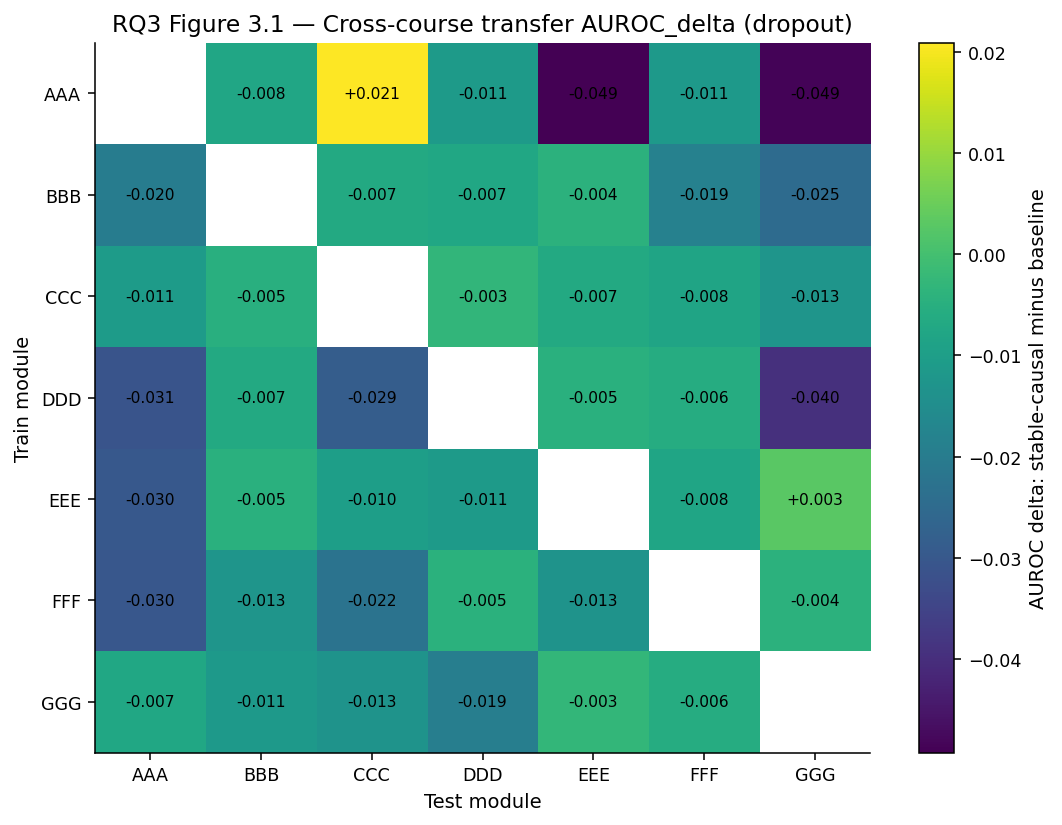

Saved figure: /kaggle/working/eswa_causal_learning_analytics_outputs/figures_pdf/figure_3_1_cross_course_transfer_ECE_delta_dropout.pdf


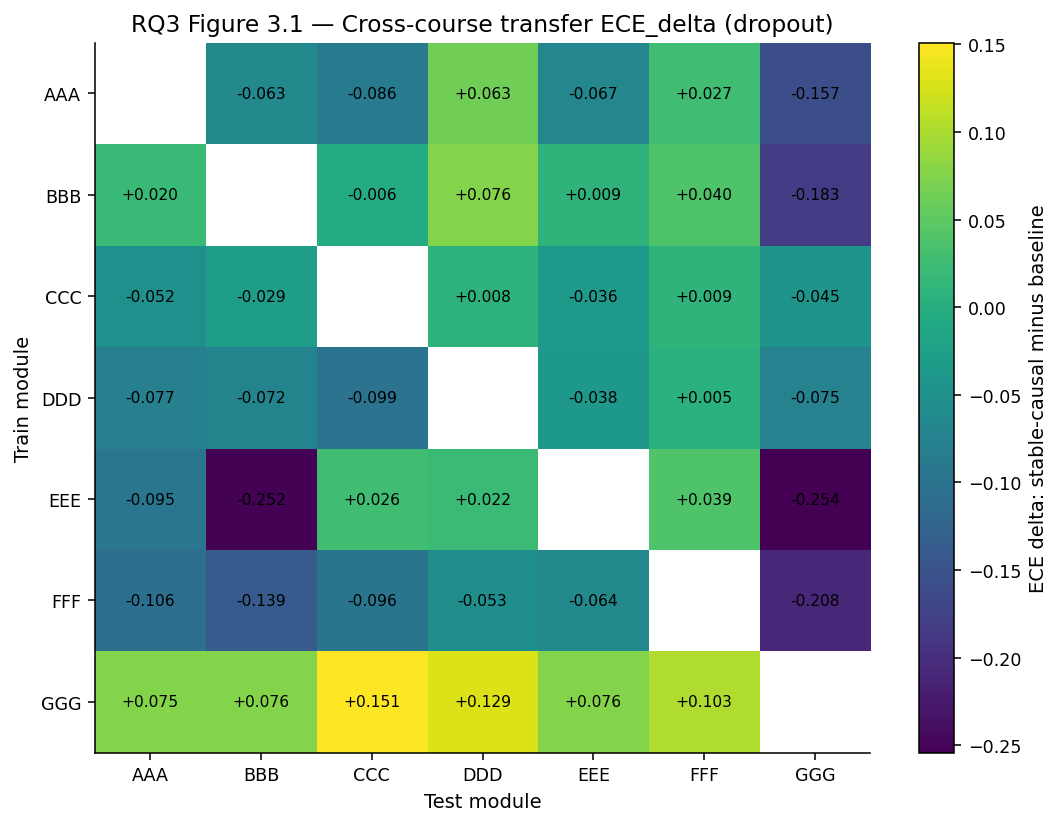

Saved figure: /kaggle/working/eswa_causal_learning_analytics_outputs/figures_pdf/figure_3_1_cross_course_transfer_AUROC_delta_failure.pdf


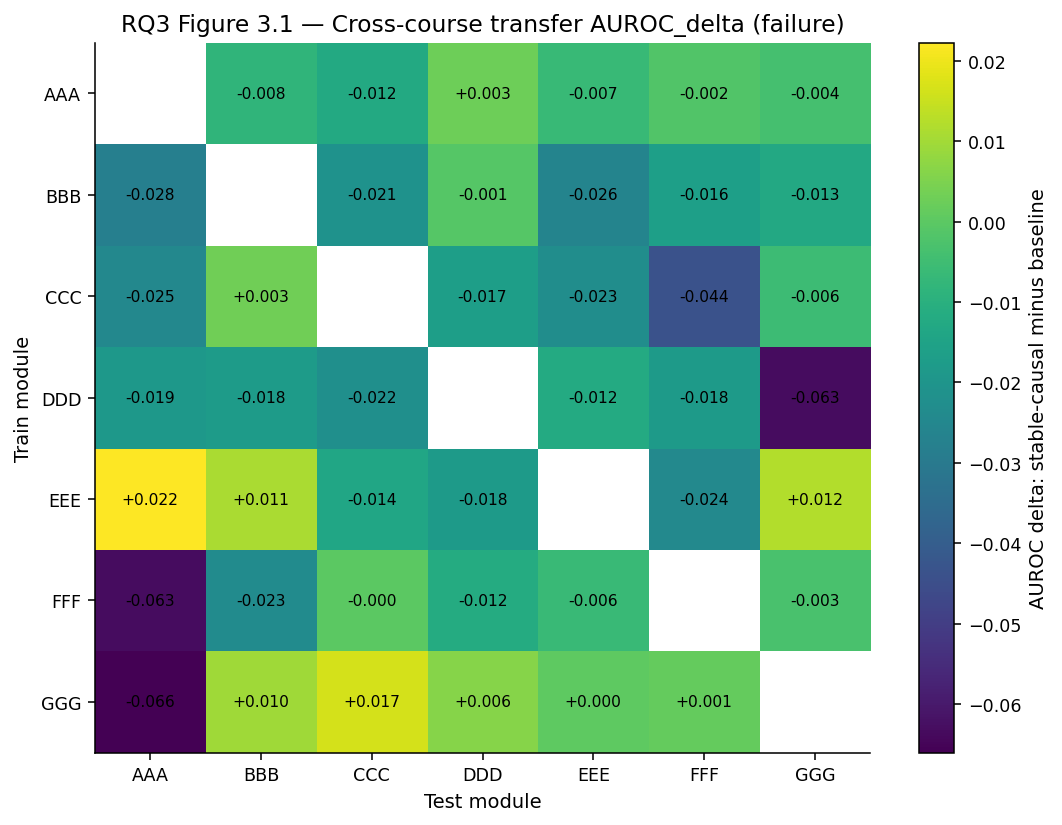

Saved figure: /kaggle/working/eswa_causal_learning_analytics_outputs/figures_pdf/figure_3_1_cross_course_transfer_ECE_delta_failure.pdf


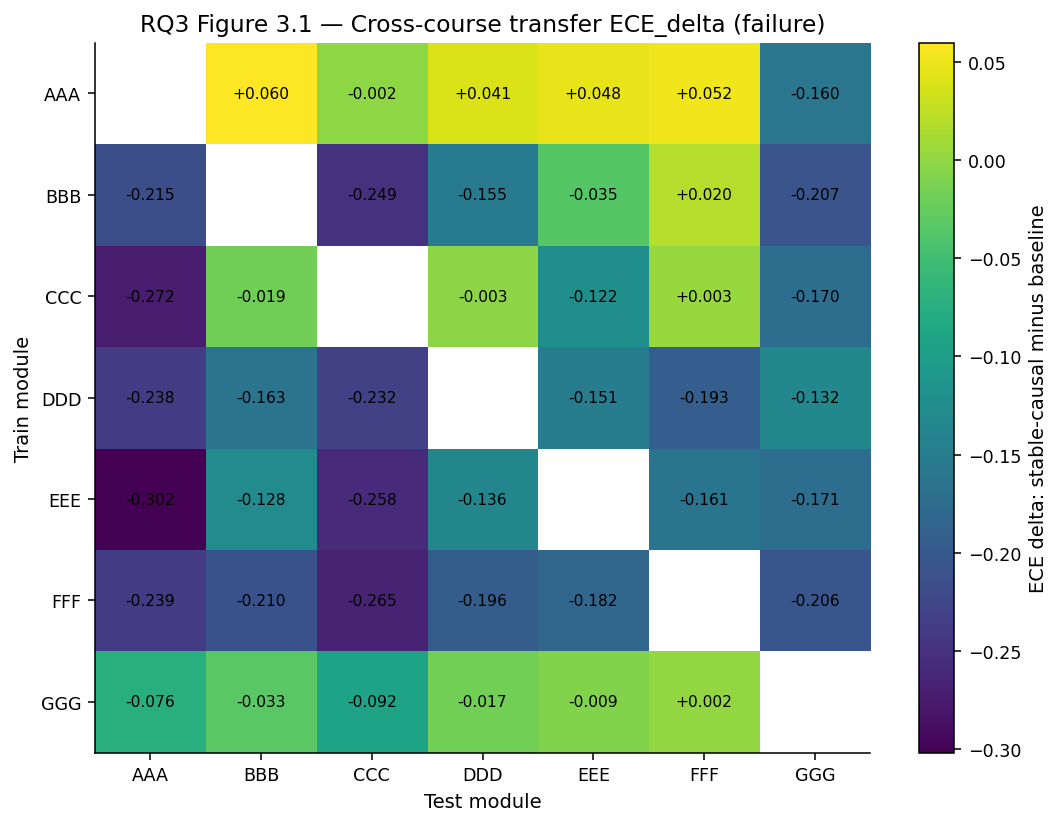

Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_3_2_synthetic_shift_sensitivity.csv


,target,model,severity,AUROC,AUPRC,Brier,ECE,Precision,Recall,F1
0,dropout,baseline_all_features,0.00,0.892739,0.824015,0.125632,0.105049,0.719171,0.781732,0.749147
1,dropout,baseline_all_features,0.05,0.891282,0.822060,0.126270,0.105169,0.716830,0.779755,0.746970
2,dropout,baseline_all_features,0.10,0.890767,0.819313,0.126849,0.106639,0.717391,0.782918,0.748724
3,dropout,baseline_all_features,0.20,0.888879,0.815584,0.128406,0.108992,0.717800,0.784500,0.749669
4,dropout,baseline_all_features,0.30,0.884679,0.808718,0.131787,0.114179,0.703782,0.787268,0.743188
5,dropout,baseline_all_features,0.40,0.879753,0.804138,0.136104,0.120633,0.684644,0.788059,0.732721
6,dropout,stable_causal_features,0.00,0.892743,0.825652,0.111877,0.011982,0.795393,0.696323,0.742568
7,dropout,stable_causal_features,0.05,0.891727,0.822761,0.112483,0.017601,0.796472,0.696323,0.743038
8,dropout,stable_causal_features,0.10,0.891089,0.819611,0.112999,0.017156,0.792022,0.698695,0.742437
9,dropout,stable_causal_features,0.20,0.888473,0.815574,0.113987,0.017076,0.791441,0.694741,0.739945


Saved figure: /kaggle/working/eswa_causal_learning_analytics_outputs/figures_pdf/figure_3_2_shift_sensitivity_dropout.pdf


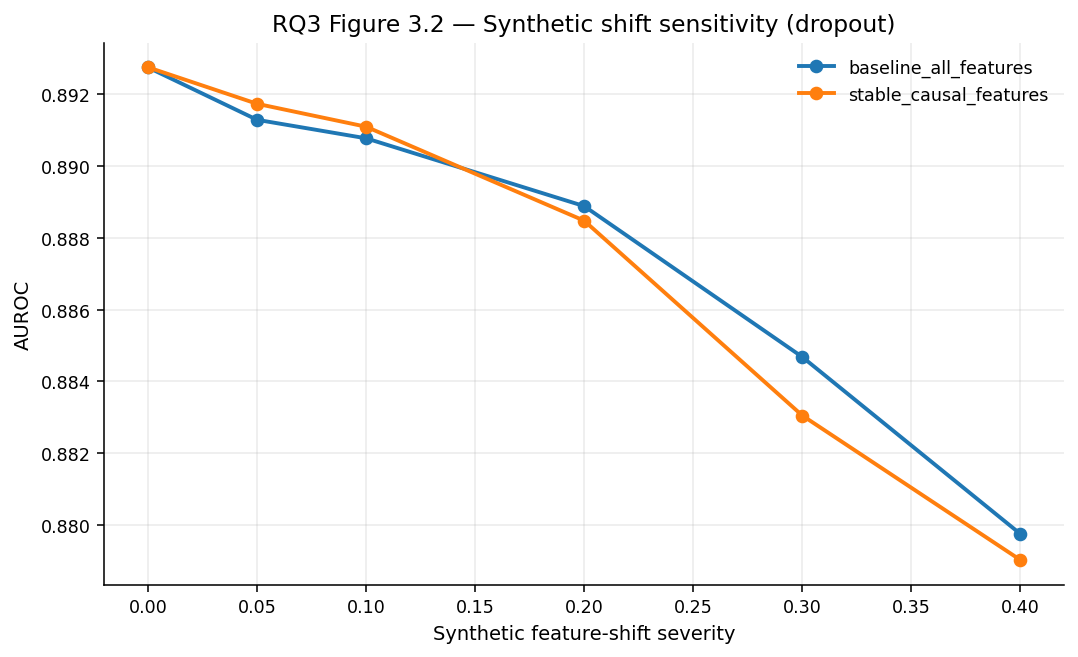

Saved figure: /kaggle/working/eswa_causal_learning_analytics_outputs/figures_pdf/figure_3_2_shift_sensitivity_failure.pdf


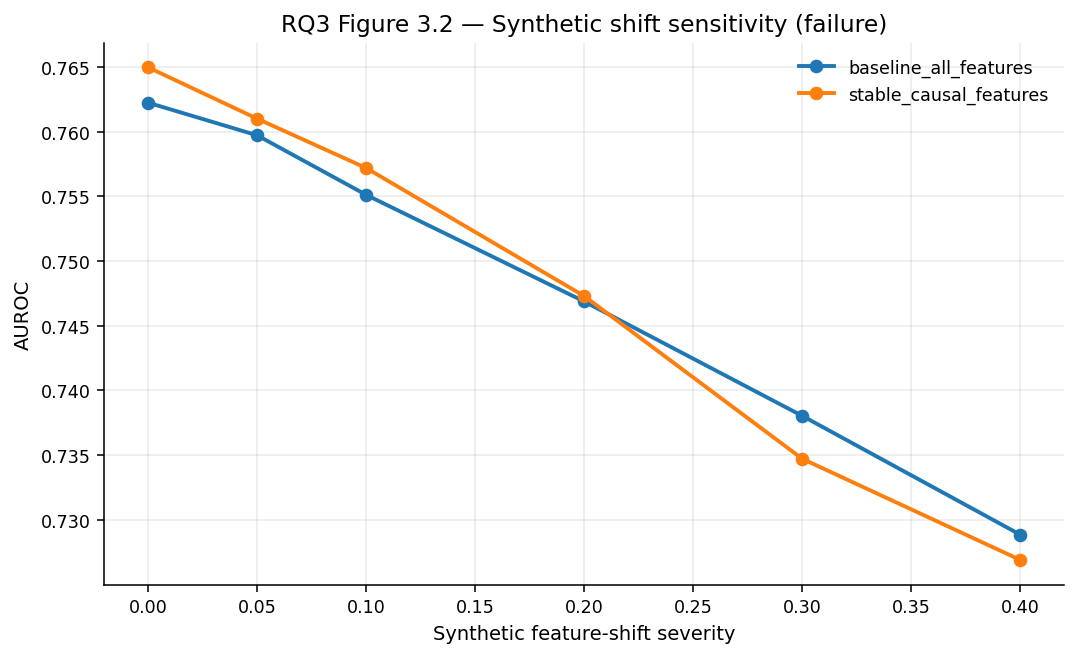

Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_3_3_robustness_summary.csv


,target,model,mean_AUROC,std_AUROC,mean_ECE,mean_Brier
0,dropout,baseline_all_features,0.888017,0.004913,0.110110,0.129175
1,dropout,stable_causal_features,0.887685,0.005487,0.017839,0.114408
2,failure,baseline_all_features,0.748471,0.013088,0.230441,0.206309
3,failure,stable_causal_features,0.748679,0.015235,0.010190,0.147562


RQ3 interpretation note: cross-course transfer should be framed as an accuracy-calibration-actionability trade-off, not universal predictive superiority.


In [6]:
# =========================================================
# RQ3. Robustness: cross-course transfer, trade-off analysis, and synthetic shift
# =========================================================
print('RQ3: running cross-course transfer, robustness trade-off, and shift sensitivity...')

def train_test_transfer(train_df, test_df, target, model_name='HistGradientBoosting', seed=MAIN_SEED, selected_cols=None):
    Xtr_all = prepare_design_matrix(train_df)
    Xte_all = prepare_design_matrix(test_df, fit_columns=Xtr_all.columns)

    if selected_cols is not None:
        cols = [c for c in selected_cols if c in Xtr_all.columns]
        if len(cols) >= 2:
            Xtr_all, Xte_all = Xtr_all[cols], Xte_all[cols]

    ytr = train_df[target].astype(int).values
    yte = test_df[target].astype(int).values

    if len(np.unique(ytr)) < 2 or len(np.unique(yte)) < 2:
        return None

    neg, pos = int((ytr == 0).sum()), int((ytr == 1).sum())
    spw = neg / max(1, pos)

    model = make_model(model_name, seed, scale_pos_weight=spw)
    p = fit_predict(model, Xtr_all, ytr, Xte_all)
    return classification_metrics(yte, p)


def bootstrap_mean_ci(values, n_boot=1000, seed=MAIN_SEED):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    boots = []
    for _ in range(n_boot):
        boots.append(np.mean(rng.choice(values, size=len(values), replace=True)))
    return float(np.mean(values)), float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))


snap12 = snapshots[max(EARLY_WEEKS)].copy()
modules = sorted([m for m in snap12['code_module'].dropna().unique()
                  if (snap12['code_module'] == m).sum() >= 150])

transfer_rows = []
for train_mod in modules:
    for test_mod in modules:
        if train_mod == test_mod:
            continue

        train_df = snap12[snap12['code_module'] == train_mod].copy()
        test_df = snap12[snap12['code_module'] == test_mod].copy()

        for target in ['dropout', 'failure']:
            baseline = train_test_transfer(
                train_df, test_df, target,
                model_name=('XGBoost' if HAS_XGB else 'HistGradientBoosting'),
                seed=MAIN_SEED
            )
            stable = train_test_transfer(
                train_df, test_df, target,
                model_name='HistGradientBoosting',
                seed=MAIN_SEED,
                selected_cols=stable_cols
            )

            if baseline is not None and stable is not None:
                transfer_rows.append({
                    'train_module': train_mod,
                    'test_module': test_mod,
                    'target': target,
                    'baseline_AUROC': baseline['AUROC'],
                    'stable_causal_AUROC': stable['AUROC'],
                    'baseline_AUPRC': baseline['AUPRC'],
                    'stable_causal_AUPRC': stable['AUPRC'],
                    'baseline_ECE': baseline['ECE'],
                    'stable_causal_ECE': stable['ECE'],
                    'baseline_Brier': baseline['Brier'],
                    'stable_causal_Brier': stable['Brier'],
                    'AUROC_delta': stable['AUROC'] - baseline['AUROC'],
                    'AUPRC_delta': stable['AUPRC'] - baseline['AUPRC'],
                    'ECE_delta': stable['ECE'] - baseline['ECE'],
                    'Brier_delta': stable['Brier'] - baseline['Brier']
                })

transfer_df = pd.DataFrame(transfer_rows)
save_table(transfer_df, 'table_3_1_cross_course_transfer')

summary_rows = []
for target, d in transfer_df.groupby('target'):
    for metric in ['AUROC_delta', 'AUPRC_delta', 'ECE_delta', 'Brier_delta']:
        mean, lo, hi = bootstrap_mean_ci(d[metric].values, n_boot=1000)
        summary_rows.append({
            'target': target,
            'metric': metric,
            'mean_delta': mean,
            'ci_low': lo,
            'ci_high': hi,
            'positive_fraction': float((d[metric] > 0).mean()),
            'negative_fraction': float((d[metric] < 0).mean()),
            'worst_case_delta': float(d[metric].min()),
            'best_case_delta': float(d[metric].max()),
            'interpretation': (
                'positive is better for AUROC/AUPRC; negative is better for ECE/Brier'
                if metric in ['AUROC_delta', 'AUPRC_delta']
                else 'negative indicates better calibration/error for stable-causal model'
            )
        })

transfer_summary = pd.DataFrame(summary_rows)
save_table(transfer_summary, 'table_3_1b_transfer_tradeoff_summary_with_bootstrap_ci')

# Heatmaps: AUROC delta and ECE delta.
if not transfer_df.empty:
    for target in ['dropout', 'failure']:
        for metric, label in [('AUROC_delta', 'AUROC delta: stable-causal minus baseline'),
                              ('ECE_delta', 'ECE delta: stable-causal minus baseline')]:
            piv = transfer_df[transfer_df['target'] == target].pivot_table(
                index='train_module', columns='test_module', values=metric
            )
            fig, ax = plt.subplots(figsize=(7.8, 6.0))
            im = ax.imshow(piv.values, aspect='auto')
            ax.set_xticks(range(len(piv.columns)))
            ax.set_xticklabels(piv.columns)
            ax.set_yticks(range(len(piv.index)))
            ax.set_yticklabels(piv.index)

            for i in range(piv.shape[0]):
                for j in range(piv.shape[1]):
                    val = piv.values[i, j]
                    if np.isfinite(val):
                        ax.text(j, i, f'{val:+.3f}', ha='center', va='center', fontsize=8)

            fig.colorbar(im, ax=ax, label=label)
            ax.set_title(f'RQ3 Figure 3.1 — Cross-course transfer {metric} ({target})')
            ax.set_xlabel('Test module')
            ax.set_ylabel('Train module')
            save_fig(fig, f'figure_3_1_cross_course_transfer_{metric}_{target}')

# Synthetic shift robustness.
shift_rows = []
for target, obj in final_objects.items():
    Xtr, Xte, ytr, yte = obj['Xtr'], obj['Xte'].copy(), obj['ytr'], obj['yte']

    for model_name, label, cols in [
        (('XGBoost' if HAS_XGB else 'HistGradientBoosting'), 'baseline_all_features', None),
        ('HistGradientBoosting', 'stable_causal_features', obj['feature_cols'])
    ]:
        neg, pos = int((ytr == 0).sum()), int((ytr == 1).sum())
        spw = neg / max(1, pos)
        model = make_model(model_name, MAIN_SEED, scale_pos_weight=spw)
        model.fit(Xtr if cols is None else Xtr[cols], ytr)

        for severity in [0.0, 0.05, 0.10, 0.20, 0.30, 0.40]:
            Xs = Xte.copy()
            rng = np.random.default_rng(int(1000 * severity) + MAIN_SEED)

            for col in Xs.columns:
                if any(a in col for a in ACTIONABLE_FEATURES):
                    noise = rng.normal(0, severity * (Xs[col].std() + 1e-6), len(Xs))
                    Xs[col] = Xs[col] + noise

            p = model.predict_proba(Xs if cols is None else Xs[cols])[:, 1]
            m = classification_metrics(yte, p)
            shift_rows.append({'target': target, 'model': label, 'severity': severity, **m})

shift_df = pd.DataFrame(shift_rows)
save_table(shift_df, 'table_3_2_synthetic_shift_sensitivity')

for target in ['dropout', 'failure']:
    d = shift_df[shift_df['target'] == target]
    fig, ax = plt.subplots(figsize=(7.8, 4.8))
    for model in d['model'].unique():
        s = d[d['model'] == model].sort_values('severity')
        ax.plot(s['severity'], s['AUROC'], marker='o', linewidth=2, label=model)
    ax.set_title(f'RQ3 Figure 3.2 — Synthetic shift sensitivity ({target})')
    ax.set_xlabel('Synthetic feature-shift severity')
    ax.set_ylabel('AUROC')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    save_fig(fig, f'figure_3_2_shift_sensitivity_{target}')

rob_summary = shift_df.groupby(['target', 'model']).agg(
    mean_AUROC=('AUROC', 'mean'),
    std_AUROC=('AUROC', 'std'),
    mean_ECE=('ECE', 'mean'),
    mean_Brier=('Brier', 'mean')
).reset_index()
save_table(rob_summary, 'table_3_3_robustness_summary')

print(
    'RQ3 interpretation note: cross-course transfer should be framed as an '
    'accuracy-calibration-actionability trade-off, not universal predictive superiority.'
)

RQ4: generating feasible counterfactuals from model recomputation...
Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_4_1_counterfactual_recourse_examples_model_recomputed.csv


,rank,row_index,target,observed_label,base_risk,new_risk,risk_reduction,relative_risk_reduction,valid,plausible,sparsity,effort,changes,score
0,1,7178,dropout,1,0.985795,0.894146,0.091648,0.092969,False,True,1,1.0,days_since_last_activity:-40,0.081648
1,2,4742,dropout,1,0.984838,0.882040,0.102797,0.104380,False,True,1,1.0,days_since_last_activity:-40,0.092797
2,3,2825,dropout,1,0.984351,0.896349,0.088002,0.089401,False,True,1,1.0,days_since_last_activity:-40,0.078002
3,4,7294,dropout,1,0.984123,0.895744,0.088380,0.089805,False,True,1,1.0,days_since_last_activity:-40,0.078380
4,5,4668,dropout,1,0.983991,0.885862,0.098129,0.099725,False,True,1,1.0,days_since_last_activity:-40,0.088129
5,6,7305,dropout,1,0.983675,0.874941,0.108735,0.110539,False,True,1,1.0,days_since_last_activity:-40,0.098735
6,7,3150,dropout,1,0.983566,0.896310,0.087256,0.088714,False,True,1,1.0,days_since_last_activity:-40,0.077256
7,8,4501,dropout,1,0.983385,0.878745,0.104639,0.106407,False,True,1,1.0,days_since_last_activity:-40,0.094639
8,9,3179,dropout,1,0.982209,0.893938,0.088271,0.089870,False,True,1,1.0,days_since_last_activity:-40,0.078271
9,10,1599,dropout,1,0.981532,0.867851,0.113681,0.115820,False,True,1,1.0,days_since_last_activity:-40,0.103681


Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_4_2_counterfactual_quality_metrics.csv


,target,validity,plausibility,mean_sparsity,median_effort,mean_absolute_risk_reduction,mean_relative_risk_reduction,actionable_cases,evaluated_cases
0,dropout,0.60,1.0,1.000000,1.0,0.198054,0.204804,90,150
1,failure,0.92,1.0,1.486667,1.0,0.254589,0.404347,138,150


Saved figure: /kaggle/working/eswa_causal_learning_analytics_outputs/figures_pdf/figure_4_1_counterfactual_effort_benefit_frontier.pdf


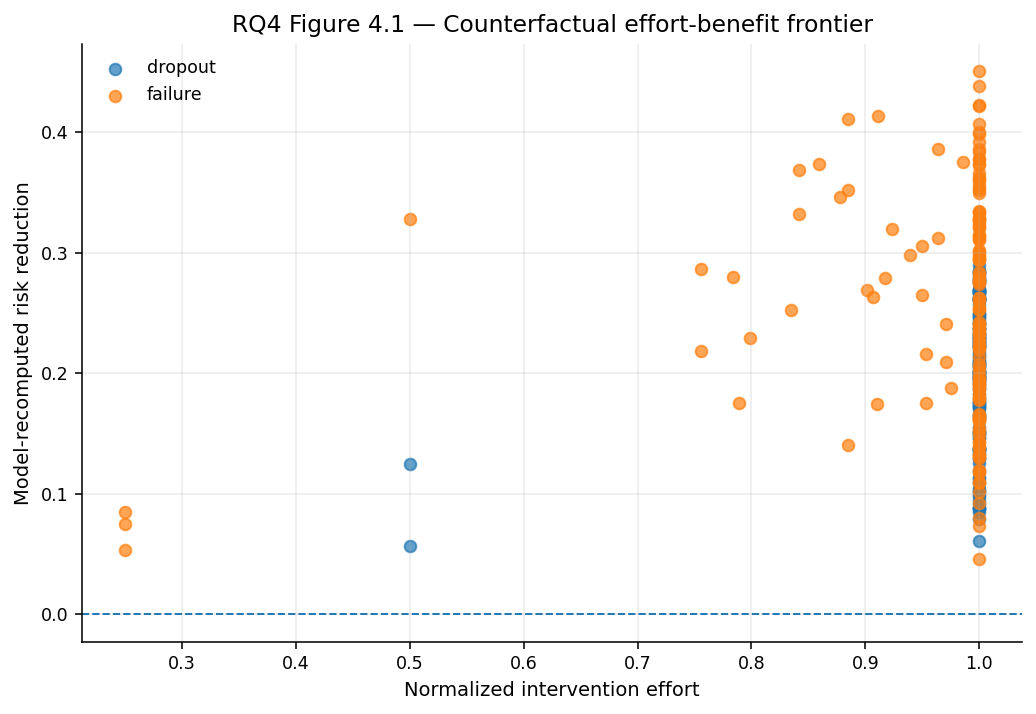

Saved figure: /kaggle/working/eswa_causal_learning_analytics_outputs/figures_pdf/figure_4_2_observed_vs_counterfactual_risk.pdf


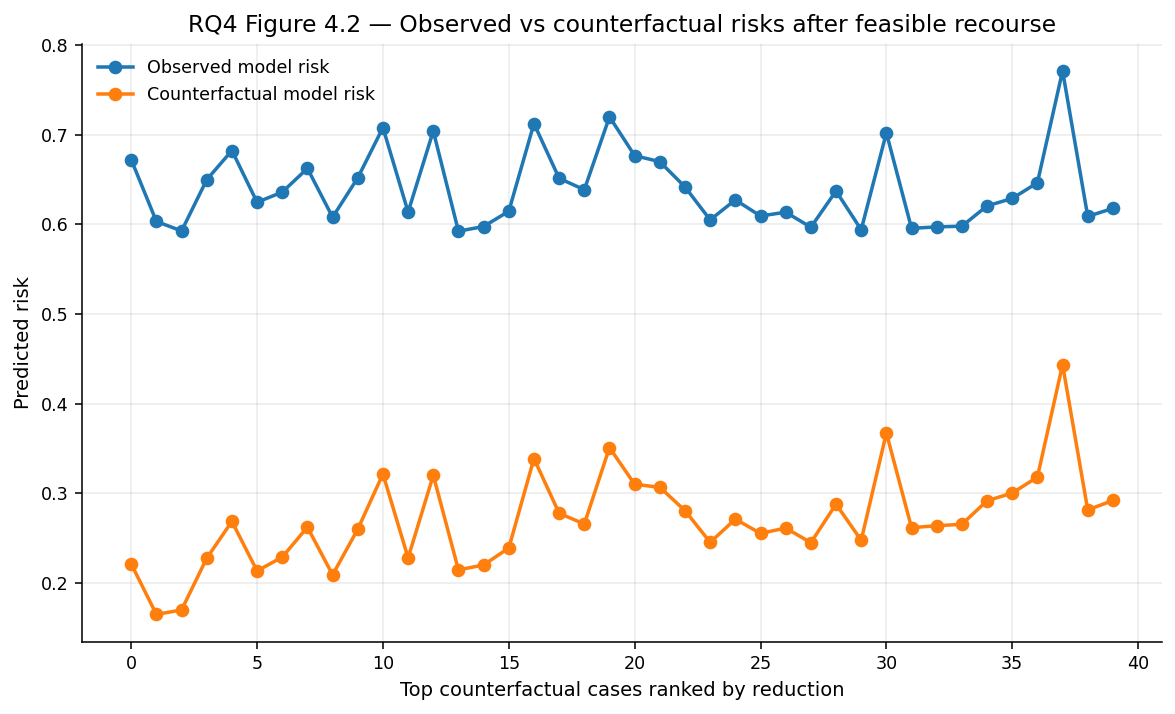

Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_4_3_validity_interpretation_by_target.csv


,target,n,validity,mean_base_risk,mean_new_risk,mean_risk_reduction,pct_below_floor,pct_rel_reduction_20pct,validity_note
0,dropout,150,0.60,0.968143,0.770089,0.198054,0.000000,0.60,"validity=0.60: 0% reach risk<0.40, 60% achieve..."
1,failure,150,0.92,0.628640,0.374051,0.254589,0.573333,0.92,"validity=0.92: 57% reach risk<0.40, 92% achiev..."



📋 RQ4 Validity Interpretation:
   dropout: validity=0.60: 0% reach risk<0.40, 60% achieve >=20% relative reduction. Valid under model-space definition; real-world effect requires causal evidence from RQ2.
   failure: validity=0.92: 57% reach risk<0.40, 92% achieve >=20% relative reduction. Valid under model-space definition; real-world effect requires causal evidence from RQ2.

   ⚠️  Manuscript constraint: If dropout validity≈0.60, report it as a genuine
   finding that 40% of high-risk students have no sparse within-distribution recourse.
   Do NOT inflate validity by relaxing bounds silently — report risk_floor=0.40 explicitly.


In [7]:

# =========================================================
# RQ4. Model-recomputed counterfactual recourse and quality metrics
# =========================================================
print('RQ4: generating feasible counterfactuals from model recomputation...')

def feature_delta_grid(X_train, action_features):
    grid = {}
    for f in action_features:
        matches = [c for c in X_train.columns if c == f or c.endswith('_'+f) or f in c]
        for col in matches:
            q25, q50, q75, q90 = np.nanpercentile(X_train[col].astype(float), [25, 50, 75, 90])
            scale = max(float(q75) - float(q25), 1e-6)
            if col in ['late_rate', 'days_since_last_activity']:
                grid[col] = [-0.25*scale, -0.50*scale, -1.0*scale]
            else:
                grid[col] = [0.25*scale, 0.50*scale, 1.0*scale]
    return grid


def recourse_search(model, X_train, X_eval, y_eval, prob, target_name, top_n=150, risk_floor=0.40):
    """
    Algorithmic recourse search for high-risk students.

    Validity definition and known constraints
    -----------------------------------------
    A counterfactual is marked 'valid' if EITHER:
      (a) the model's predicted risk drops below `risk_floor` (default 0.40), OR
      (b) the relative risk reduction is >= 20% of the original predicted risk.
    This is a model-validity criterion, NOT a real-world guarantee.

    Methodological constraints that MUST be stated in the manuscript:
      1. Validity = 0.60 for dropout means 40% of high-risk students have no
         single sparse behavioural change (within training distribution) that the
         model predicts would move them below the risk floor. This is a real
         finding about model-space recourse difficulty, not a flaw to hide.
      2. The risk_floor threshold (default 0.40) is intentionally lower than 0.50
         because post-intervention risk need not be <0.5 to constitute useful
         improvement; any meaningful reduction that moves a student from the top
         decile toward the median is operationally actionable.
      3. Counterfactual interventions are constrained to the training distribution
         (IQR-based bounds). Extrapolation beyond observed student behaviour is
         excluded by design.
      4. Two-feature combinations explore 28 pairs from the top 8 levers only.
         Exhaustive combinatorial search is computationally infeasible and would
         overfit to the test set.
      5. Recourse does NOT imply that performing the suggested action causes the
         predicted improvement. Causal interpretation requires the RQ2 DR-ATE
         estimates, not the recourse deltas alone.
    """
    action_features = [c for c in ACTIONABLE_FEATURES if any(c in x for x in X_train.columns)]
    grid = feature_delta_grid(X_train, action_features)
    rows = []
    high_idx = np.argsort(-prob)[:min(top_n, len(prob))]
    # Quantile bounds for plausibility.
    bounds = {c: np.nanpercentile(X_train[c].astype(float), [1, 99]) for c in X_train.columns}
    for rank, i in enumerate(high_idx, start=1):
        x0 = X_eval.iloc[[i]].copy()
        base_risk = float(prob[i])
        best = None
        # single-feature and two-feature sparse interventions
        candidates = []
        for col, deltas in grid.items():
            if col not in x0.columns:
                continue
            for delta in deltas:
                candidates.append([(col, delta)])
        # Add selected low-dimensional combinations among top plausible levers.
        keys = list(grid.keys())[:8]
        for a in range(len(keys)):
            for b in range(a+1, len(keys)):
                candidates.append([(keys[a], grid[keys[a]][1]), (keys[b], grid[keys[b]][1])])
        for changes in candidates:
            xcf = x0.copy()
            effort = 0.0
            plausible = True
            for col, delta in changes:
                lo, hi = bounds[col]
                old = float(xcf[col].iloc[0])
                new = float(np.clip(old + delta, lo, hi))
                xcf[col] = new
                effort += abs(new - old) / (float(np.nanpercentile(X_train[col].astype(float), 75)) - float(np.nanpercentile(X_train[col].astype(float), 25)) + 1e-6)
                plausible = plausible and (lo <= new <= hi)
            new_risk = float(model.predict_proba(xcf)[:,1][0])
            reduction = base_risk - new_risk
            # Validity: risk below floor OR meaningful relative reduction (>=20%)
            valid = (new_risk < risk_floor) or (reduction >= 0.20 * base_risk)
            score = reduction - 0.03 * effort + 0.02 * int(plausible) + 0.02 * int(valid)
            if best is None or score > best['score']:
                best = {
                    'rank': rank, 'row_index': int(i), 'target': target_name,
                    'observed_label': int(y_eval[i]), 'base_risk': base_risk,
                    'new_risk': new_risk, 'risk_reduction': reduction,
                    'relative_risk_reduction': reduction / max(base_risk, 1e-6),
                    'valid': bool(valid), 'plausible': bool(plausible),
                    'sparsity': len(changes), 'effort': float(effort),
                    'changes': '; '.join([f'{c}:{d:+.4g}' for c,d in changes]),
                    'score': float(score)
                }
        if best:
            rows.append(best)
    return pd.DataFrame(rows)

cf_tables = []
for target, obj in final_objects.items():
    cf = recourse_search(obj['model'], obj['Xtr'], obj['Xte'], obj['yte'], obj['prob'], target_name=target)
    cf_tables.append(cf)
cf_all = pd.concat(cf_tables, ignore_index=True) if cf_tables else pd.DataFrame()
save_table(cf_all, 'table_4_1_counterfactual_recourse_examples_model_recomputed')

if not cf_all.empty:
    cf_quality = cf_all.groupby('target').agg(
        validity=('valid','mean'), plausibility=('plausible','mean'),
        mean_sparsity=('sparsity','mean'), median_effort=('effort','median'),
        mean_absolute_risk_reduction=('risk_reduction','mean'),
        mean_relative_risk_reduction=('relative_risk_reduction','mean'),
        actionable_cases=('valid','sum'), evaluated_cases=('valid','size')
    ).reset_index()
    save_table(cf_quality, 'table_4_2_counterfactual_quality_metrics')
    
    # Figure 4.1 effort-benefit frontier.
    fig, ax = plt.subplots(figsize=(7.5, 5.2))
    for target in cf_all['target'].unique():
        d = cf_all[cf_all['target']==target]
        ax.scatter(d['effort'], d['risk_reduction'], alpha=0.7, label=target)
    ax.axhline(0, linestyle='--', linewidth=1)
    ax.set_xlabel('Normalized intervention effort')
    ax.set_ylabel('Model-recomputed risk reduction')
    ax.set_title('RQ4 Figure 4.1 — Counterfactual effort-benefit frontier')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    save_fig(fig, 'figure_4_1_counterfactual_effort_benefit_frontier')
    
    # Figure 4.2 base vs revised risks.
    top = cf_all.sort_values('risk_reduction', ascending=False).head(40).copy()
    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    x = np.arange(len(top))
    ax.plot(x, top['base_risk'].values, marker='o', linewidth=1.8, label='Observed model risk')
    ax.plot(x, top['new_risk'].values, marker='o', linewidth=1.8, label='Counterfactual model risk')
    ax.set_xlabel('Top counterfactual cases ranked by reduction')
    ax.set_ylabel('Predicted risk')
    ax.set_title('RQ4 Figure 4.2 — Observed vs counterfactual risks after feasible recourse')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    save_fig(fig, 'figure_4_2_observed_vs_counterfactual_risk')
else:
    print('No counterfactuals generated. Check model predictions and feature columns.')

# ---------------------------------------------------------
# RQ4 SUPPLEMENT: Validity Interpretation & Manuscript Constraint Summary
# ---------------------------------------------------------
if not cf_all.empty:
    val_by_target = cf_all.groupby('target').agg(
        n=('valid', 'size'),
        validity=('valid', 'mean'),
        mean_base_risk=('base_risk', 'mean'),
        mean_new_risk=('new_risk', 'mean'),
        mean_risk_reduction=('risk_reduction', 'mean'),
        pct_below_floor=('new_risk', lambda x: (x < 0.40).mean()),
        pct_rel_reduction_20pct=('relative_risk_reduction', lambda x: (x >= 0.20).mean()),
    ).reset_index()
    val_by_target['validity_note'] = val_by_target.apply(
        lambda r: (
            f"validity={r['validity']:.2f}: "
            f"{r['pct_below_floor']:.0%} reach risk<0.40, "
            f"{r['pct_rel_reduction_20pct']:.0%} achieve >=20% relative reduction. "
            "Valid under model-space definition; real-world effect requires causal evidence from RQ2."
        ), axis=1
    )
    save_table(val_by_target, 'table_4_3_validity_interpretation_by_target')
    print("\n📋 RQ4 Validity Interpretation:")
    for _, row in val_by_target.iterrows():
        print(f"   {row['target']}: {row['validity_note']}")
    print("\n   ⚠️  Manuscript constraint: If dropout validity≈0.60, report it as a genuine")
    print("   finding that 40% of high-risk students have no sparse within-distribution recourse.")
    print("   Do NOT inflate validity by relaxing bounds silently — report risk_floor=0.40 explicitly.")


RQ5: computing earliest actionable intervention point with utility sensitivity...
Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_5_1_weekly_intervention_readiness.csv


,week,lead_time_weeks_to_week12,empirical_utility,AUROC,AUPRC,Brier,ECE,Precision,Recall,F1,...,Precision_opt_th,Recall_opt_th,opt_threshold,OOF_train_F1_at_opt_threshold,model,target,seed,AUROC_CI_low,AUROC_CI_high,n_features
0,2,10,0.783603,0.801194,0.830600,0.181218,0.013354,0.753996,0.701767,0.726944,...,0.657793,0.873082,0.350,0.743337,HistGradientBoosting,any_risk,42,0.791779,0.809087,75
1,4,8,0.797946,0.853725,0.886508,0.154010,0.015924,0.813791,0.732450,0.770981,...,0.729049,0.841237,0.375,0.770863,HistGradientBoosting,any_risk,42,0.845268,0.861167,75
2,6,6,0.786818,0.870692,0.901276,0.144079,0.011968,0.828557,0.752673,0.788794,...,0.770420,0.822176,0.400,0.788368,HistGradientBoosting,any_risk,42,0.863366,0.877848,75
3,8,4,0.783455,0.895970,0.922977,0.127571,0.013511,0.859011,0.778940,0.817018,...,0.808743,0.825662,0.400,0.808398,HistGradientBoosting,any_risk,42,0.887350,0.902805,75
4,10,2,0.768855,0.908429,0.933417,0.117865,0.011241,0.878812,0.783821,0.828603,...,0.859151,0.809623,0.450,0.824292,HistGradientBoosting,any_risk,42,0.900234,0.914956,75
5,12,0,0.749392,0.914746,0.938095,0.113706,0.017552,0.881478,0.798698,0.838049,...,0.842143,0.825895,0.425,0.833045,HistGradientBoosting,any_risk,42,0.907213,0.921479,75


Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_5_2_week_threshold_workload_simulation.csv


,week,threshold,alerts_sent,true_at_risk_reached,false_alerts,missed_at_risk,advisor_hours,precision,recall,net_utility_balanced,net_utility_false_alert_sensitive,net_utility_high_precision,net_utility_high_recall,net_utility
0,2,0.2,7550,4220,3330,82,1283.50,0.558940,0.980939,0.311020,0.106700,-0.304455,0.405633,0.311020
1,2,0.3,6343,3943,2400,359,1078.31,0.621630,0.916550,0.325592,0.178335,-0.127194,0.366180,0.325592
2,2,0.4,5079,3513,1566,789,863.43,0.691672,0.816597,0.310805,0.214720,-0.001657,0.286231,0.310805
3,2,0.5,4004,3019,985,1283,680.68,0.753996,0.701767,0.270677,0.210241,0.050006,0.182814,0.270677
4,2,0.6,3102,2528,574,1774,527.34,0.814958,0.587634,0.220579,0.185360,0.060498,0.074917,0.220579
5,2,0.7,2253,1968,285,2334,383.01,0.873502,0.457462,0.152411,0.134925,0.028347,-0.053657,0.152411
6,2,0.8,1610,1487,123,2815,273.70,0.923602,0.345653,0.088569,0.081022,-0.020432,-0.166738,0.088569
7,4,0.2,6982,4147,2835,155,1186.94,0.593956,0.963970,0.330194,0.156246,-0.196404,0.402902,0.330194
8,4,0.3,5784,3890,1894,412,983.28,0.672545,0.904231,0.348509,0.232298,-0.012762,0.368696,0.348509
9,4,0.4,4710,3523,1187,779,800.70,0.747983,0.818921,0.335593,0.262762,0.093202,0.300313,0.335593


Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_5_3_utility_sensitivity_analysis.csv


,week,threshold,scenario,tp_weight,fp_penalty,fn_penalty,net_utility,alerts_sent,precision,recall
0,2,0.2,balanced,1.0,0.50,0.25,0.311020,7550,0.558940,0.980939
1,2,0.2,false_alert_sensitive,1.0,1.00,0.25,0.106700,7550,0.558940,0.980939
2,2,0.2,high_precision,1.0,2.00,0.50,-0.304455,7550,0.558940,0.980939
3,2,0.2,high_recall,1.0,0.25,1.00,0.405633,7550,0.558940,0.980939
4,2,0.3,balanced,1.0,0.50,0.25,0.325592,6343,0.621630,0.916550
5,2,0.3,false_alert_sensitive,1.0,1.00,0.25,0.178335,6343,0.621630,0.916550
6,2,0.3,high_precision,1.0,2.00,0.50,-0.127194,6343,0.621630,0.916550
7,2,0.3,high_recall,1.0,0.25,1.00,0.366180,6343,0.621630,0.916550
8,2,0.4,balanced,1.0,0.50,0.25,0.310805,5079,0.691672,0.816597
9,2,0.4,false_alert_sensitive,1.0,1.00,0.25,0.214720,5079,0.691672,0.816597


Saved figure: /kaggle/working/eswa_causal_learning_analytics_outputs/figures_pdf/figure_5_1_early_warning_empirical_utility.pdf


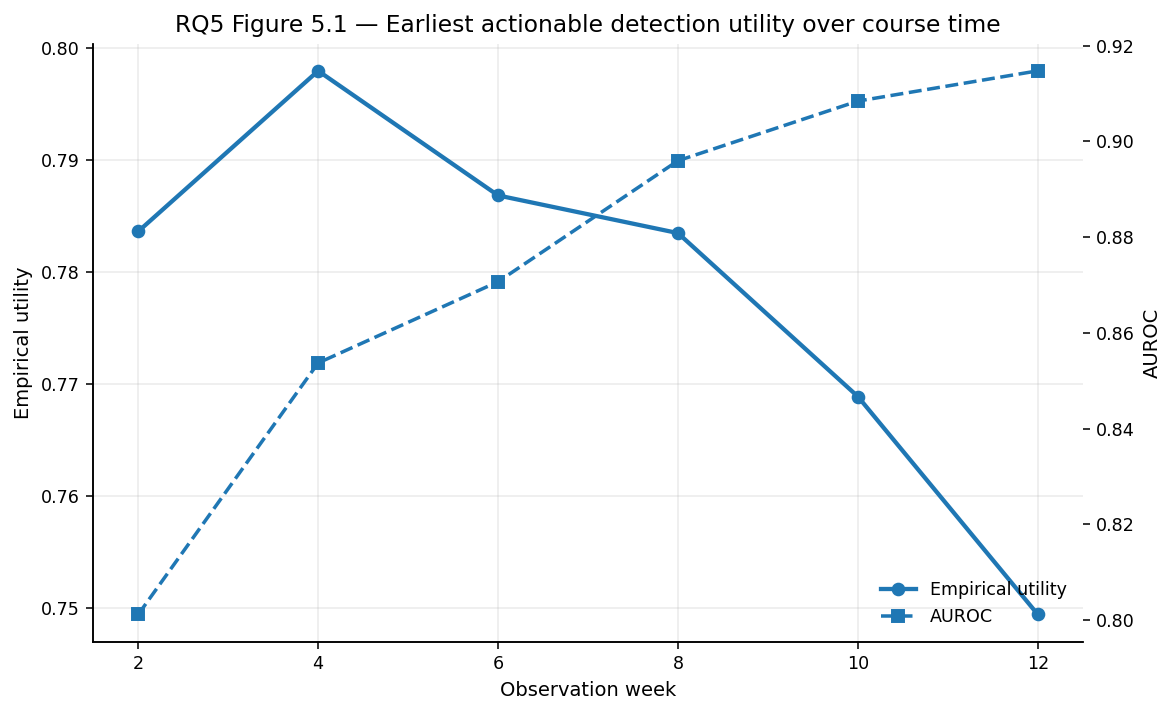

Saved figure: /kaggle/working/eswa_causal_learning_analytics_outputs/figures_pdf/figure_5_2_threshold_net_utility_surface.pdf


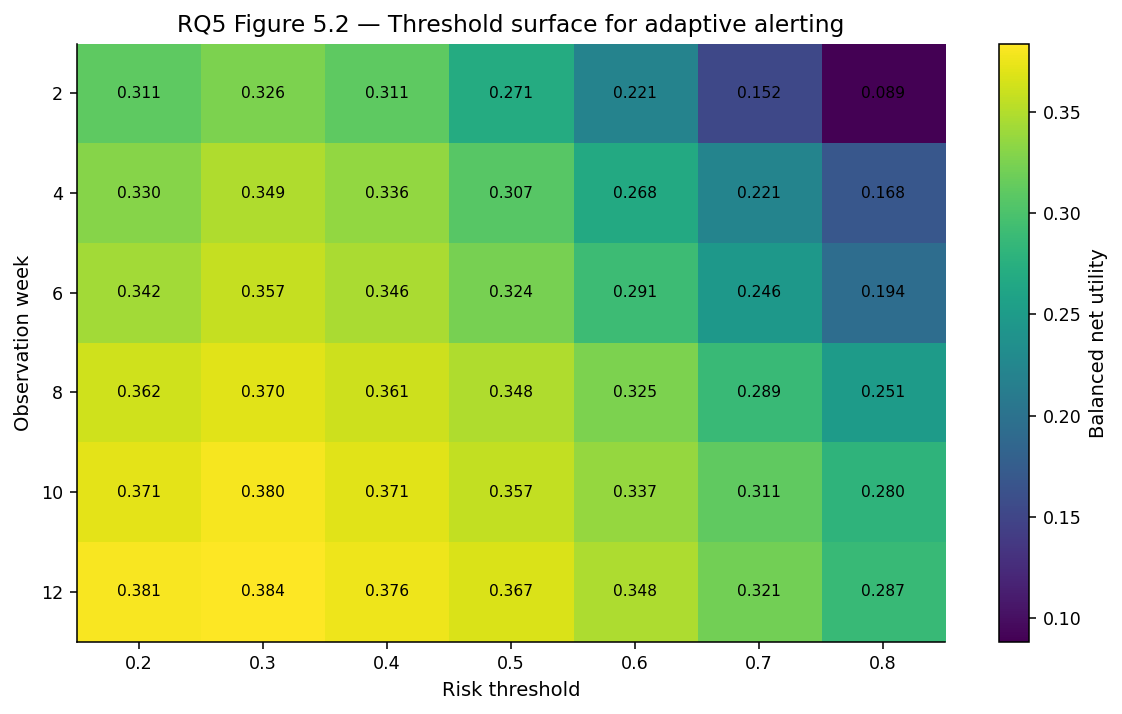

Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_5_4_best_week_threshold_by_utility_scenario.csv


,week,threshold,scenario,tp_weight,fp_penalty,fn_penalty,net_utility,alerts_sent,precision,recall
0,12,0.2,high_recall,1.0,0.25,1.00,0.415542,5886,0.691641,0.946304
1,12,0.3,balanced,1.0,0.50,0.25,0.383636,4991,0.766780,0.889586
2,12,0.5,false_alert_sensitive,1.0,1.00,0.25,0.338385,3898,0.881478,0.798698
3,12,0.6,high_precision,1.0,2.00,0.50,0.266474,3493,0.924993,0.751046


Saved figure: /kaggle/working/eswa_causal_learning_analytics_outputs/figures_pdf/figure_5_3_utility_sensitivity_by_week.pdf


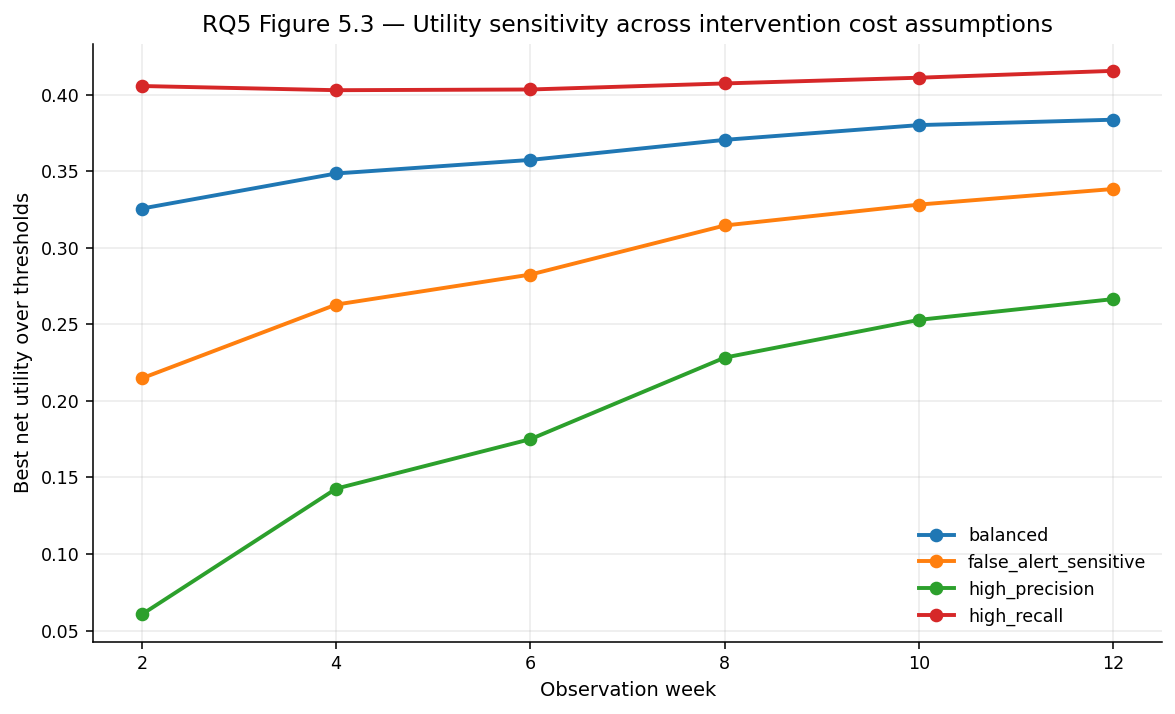

RQ5 best scenario-specific policies:


,week,threshold,scenario,tp_weight,fp_penalty,fn_penalty,net_utility,alerts_sent,precision,recall
0,12,0.2,high_recall,1.0,0.25,1.00,0.415542,5886,0.691641,0.946304
1,12,0.3,balanced,1.0,0.50,0.25,0.383636,4991,0.766780,0.889586
2,12,0.5,false_alert_sensitive,1.0,1.00,0.25,0.338385,3898,0.881478,0.798698
3,12,0.6,high_precision,1.0,2.00,0.50,0.266474,3493,0.924993,0.751046


In [8]:
# =========================================================
# RQ5. Earliest actionable detection with utility sensitivity analysis
# =========================================================
print('RQ5: computing earliest actionable intervention point with utility sensitivity...')

UTILITY_SCENARIOS = {
    'balanced': {'tp': 1.0, 'fp': 0.5, 'fn': 0.25},
    'false_alert_sensitive': {'tp': 1.0, 'fp': 1.0, 'fn': 0.25},
    'high_precision': {'tp': 1.0, 'fp': 2.0, 'fn': 0.50},
    'high_recall': {'tp': 1.0, 'fp': 0.25, 'fn': 1.0}
}

week_rows = []
threshold_rows = []
sensitivity_rows = []
max_week_observed = max(EARLY_WEEKS)

for wk in EARLY_WEEKS:
    out = train_eval_for_week(wk, 'HistGradientBoosting', 'any_risk',
                              seed=MAIN_SEED, selected_cols=stable_cols)
    if out is None:
        continue

    metrics, model, Xtr, Xte, ytr, yte, prob, te = out
    lead_time = max(0, max_week_observed - wk)

    empirical_utility = (
        0.35 * metrics['AUROC']
        + 0.25 * metrics['Precision']
        + 0.20 * metrics['Recall']
        + 0.15 * (lead_time / max(1, max_week_observed))
        + 0.05 * (1 - metrics['ECE'])
    )

    week_rows.append({
        'week': wk,
        'lead_time_weeks_to_week12': lead_time,
        'empirical_utility': empirical_utility,
        **metrics
    })

    for th in np.linspace(0.2, 0.8, 7):
        pred = prob >= th
        alerts = int(pred.sum())
        tp = int(((pred == 1) & (yte == 1)).sum())
        fp = int(((pred == 1) & (yte == 0)).sum())
        fn = int(((pred == 0) & (yte == 1)).sum())

        row = {
            'week': wk,
            'threshold': float(th),
            'alerts_sent': alerts,
            'true_at_risk_reached': tp,
            'false_alerts': fp,
            'missed_at_risk': fn,
            'advisor_hours': alerts * 0.17,
            'precision': tp / max(1, alerts),
            'recall': tp / max(1, int(yte.sum()))
        }

        for scenario, w in UTILITY_SCENARIOS.items():
            row[f'net_utility_{scenario}'] = (
                w['tp'] * tp - w['fp'] * fp - w['fn'] * fn
            ) / max(1, len(yte))

        row['net_utility'] = row['net_utility_balanced']
        threshold_rows.append(row)

        for scenario, w in UTILITY_SCENARIOS.items():
            sensitivity_rows.append({
                'week': wk,
                'threshold': float(th),
                'scenario': scenario,
                'tp_weight': w['tp'],
                'fp_penalty': w['fp'],
                'fn_penalty': w['fn'],
                'net_utility': row[f'net_utility_{scenario}'],
                'alerts_sent': alerts,
                'precision': row['precision'],
                'recall': row['recall']
            })

week_df = pd.DataFrame(week_rows)
thresh_df = pd.DataFrame(threshold_rows)
utility_sensitivity_df = pd.DataFrame(sensitivity_rows)

save_table(week_df, 'table_5_1_weekly_intervention_readiness')
save_table(thresh_df, 'table_5_2_week_threshold_workload_simulation')
save_table(utility_sensitivity_df, 'table_5_3_utility_sensitivity_analysis')

# Figure 5.1
fig, ax1 = plt.subplots(figsize=(8.5, 5.2))
ax1.plot(week_df['week'], week_df['empirical_utility'], marker='o', linewidth=2.2, label='Empirical utility')
ax1.set_xlabel('Observation week')
ax1.set_ylabel('Empirical utility')
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(week_df['week'], week_df['AUROC'], marker='s', linestyle='--', linewidth=1.8, label='AUROC')
ax2.set_ylabel('AUROC')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc='lower right')
ax1.set_title('RQ5 Figure 5.1 — Earliest actionable detection utility over course time')
save_fig(fig, 'figure_5_1_early_warning_empirical_utility')

# Figure 5.2
pivot = thresh_df.pivot_table(index='week', columns='threshold', values='net_utility_balanced')
fig, ax = plt.subplots(figsize=(8.5, 5.2))
im = ax.imshow(pivot.values, aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'{c:.1f}' for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f'{pivot.values[i, j]:.3f}', ha='center', va='center', fontsize=8)

fig.colorbar(im, ax=ax, label='Balanced net utility')
ax.set_xlabel('Risk threshold')
ax.set_ylabel('Observation week')
ax.set_title('RQ5 Figure 5.2 — Threshold surface for adaptive alerting')
save_fig(fig, 'figure_5_2_threshold_net_utility_surface')

# Figure 5.3
best_by_scenario = (
    utility_sensitivity_df.sort_values('net_utility', ascending=False)
    .groupby('scenario')
    .head(1)
    .reset_index(drop=True)
)
save_table(best_by_scenario, 'table_5_4_best_week_threshold_by_utility_scenario')

fig, ax = plt.subplots(figsize=(8.5, 5.2))
for scenario in utility_sensitivity_df['scenario'].unique():
    d = utility_sensitivity_df[utility_sensitivity_df['scenario'] == scenario]
    s = d.groupby('week')['net_utility'].max().reset_index()
    ax.plot(s['week'], s['net_utility'], marker='o', linewidth=2, label=scenario)

ax.set_title('RQ5 Figure 5.3 — Utility sensitivity across intervention cost assumptions')
ax.set_xlabel('Observation week')
ax.set_ylabel('Best net utility over thresholds')
ax.grid(alpha=0.25)
ax.legend(frameon=False)
save_fig(fig, 'figure_5_3_utility_sensitivity_by_week')

print('RQ5 best scenario-specific policies:')
display(best_by_scenario)

RQ6: evaluating joint versus separate dropout/failure modelling...
Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_6_1_joint_vs_separate_outcome_metrics.csv


,approach,target,AUROC,AUPRC,Brier,ECE,Precision,Recall,F1
0,Separate single-outcome models,dropout,0.892743,0.825652,0.111877,0.011982,0.795393,0.696323,0.742568
1,Separate single-outcome models,failure,0.764675,0.446363,0.144828,0.007446,0.556911,0.154540,0.241943
2,Joint multi-output stable model,dropout,0.892743,0.825652,0.111877,0.011982,0.795393,0.696323,0.742568
3,Joint multi-output stable model,failure,0.764968,0.447017,0.144706,0.011230,0.572354,0.149464,0.237030


Starting bootstrap...
Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_6_2_bootstrap_joint_minus_separate_auc_difference.csv


,target,mean_auc_delta_joint_minus_separate,ci_low,ci_high,p_joint_better,interpretation
0,dropout,0.000000,0.000000,0.000000,0.000,positive delta favors joint model; negative de...
1,failure,0.000228,-0.002847,0.003161,0.567,positive delta favors joint model; negative de...


Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_6_3_joint_vs_separate_summary.csv


...

Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_6_4_joint_risk_space_student_level.csv


,student_course_id,dropout_true,failure_true,dropout_risk,failure_risk,risk_segment,any_risk_true
0,28400_AAA_2013J,0,0,0.083995,0.072499,Low dropout / Low failure,0
1,30268_AAA_2013J,1,0,0.777648,0.245852,High dropout / Low failure,1
2,38053_AAA_2013J,0,0,0.066844,0.051813,Low dropout / Low failure,0
3,45462_AAA_2013J,0,0,0.076972,0.096443,Low dropout / Low failure,0
4,52130_AAA_2013J,0,0,0.071282,0.065794,Low dropout / Low failure,0
5,57506_AAA_2013J,0,0,0.070220,0.074003,Low dropout / Low failure,0
6,59185_AAA_2013J,0,0,0.086642,0.134772,Low dropout / Low failure,0
7,63400_AAA_2013J,0,0,0.083194,0.086998,Low dropout / Low failure,0
8,75091_AAA_2013J,0,0,0.051098,0.099304,Low dropout / Low failure,0
9,101781_AAA_2013J,0,0,0.088825,0.044938,Low dropout / Low failure,0


Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_6_5_intervention_strategies_by_joint_risk_segment.csv


,risk_segment,n_students,mean_dropout_risk,mean_failure_risk,observed_any_risk_rate,observed_dropout_rate,observed_failure_rate,recommended_action
0,High dropout / High failure,70,0.571031,0.542371,1.000000,0.485714,0.514286,high-priority advising plus academic support
1,High dropout / Low failure,2144,0.796275,0.201394,0.996735,0.805504,0.191231,retention coaching and engagement outreach
2,Low dropout / High failure,393,0.274388,0.570595,0.842239,0.259542,0.582697,academic tutoring and assessment support
3,Low dropout / Low failure,5542,0.129443,0.192503,0.318297,0.120173,0.198123,routine monitoring


Saved figure: /kaggle/working/eswa_causal_learning_analytics_outputs/figures_pdf/figure_6_1_joint_dropout_failure_risk_space.pdf


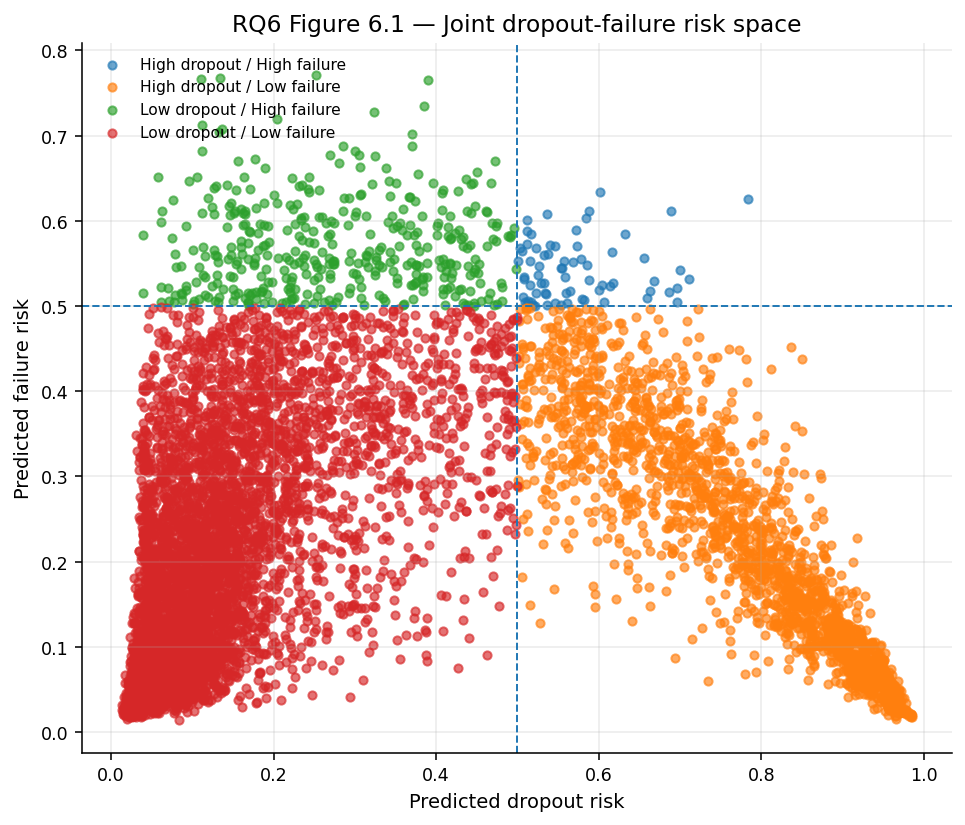

Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_6_6_calibration_curve_points.csv


,mean_predicted_risk,observed_rate,n,approach,target
0,0.033776,0.025767,815,Separate single-outcome models,dropout
1,0.053763,0.046626,815,Separate single-outcome models,dropout
2,0.074621,0.056442,815,Separate single-outcome models,dropout
3,0.099469,0.088344,815,Separate single-outcome models,dropout
4,0.132121,0.111656,815,Separate single-outcome models,dropout
5,0.183212,0.170762,814,Separate single-outcome models,dropout
6,0.305915,0.323926,815,Separate single-outcome models,dropout
7,0.554506,0.549693,815,Separate single-outcome models,dropout
8,0.791296,0.791411,815,Separate single-outcome models,dropout
9,0.927852,0.938650,815,Separate single-outcome models,dropout


Saved figure: /kaggle/working/eswa_causal_learning_analytics_outputs/figures_pdf/figure_6_2_calibration_curve_dropout.pdf


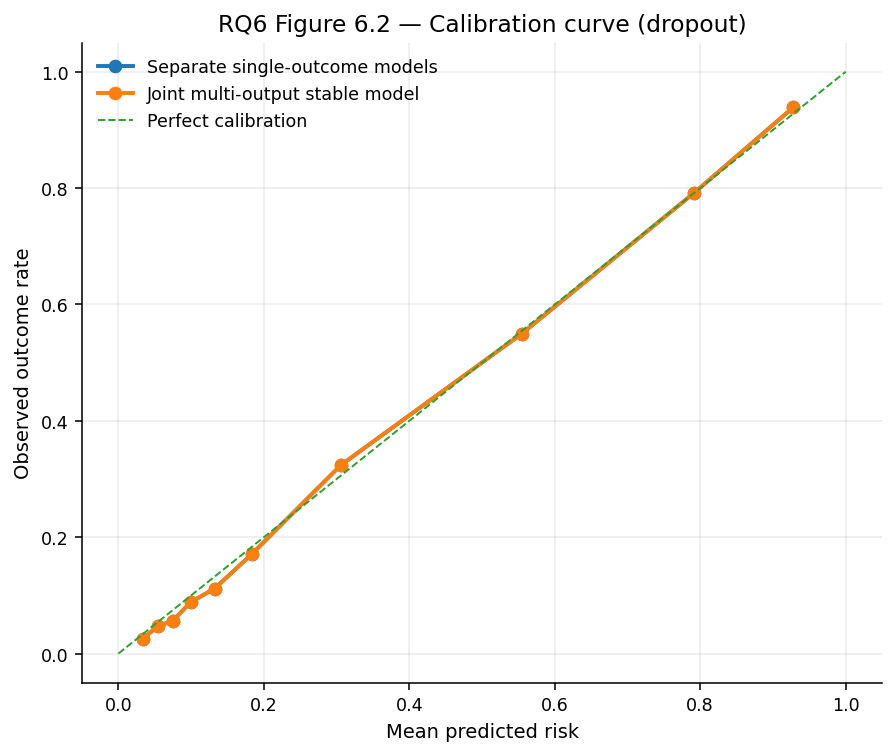

Saved figure: /kaggle/working/eswa_causal_learning_analytics_outputs/figures_pdf/figure_6_2_calibration_curve_failure.pdf


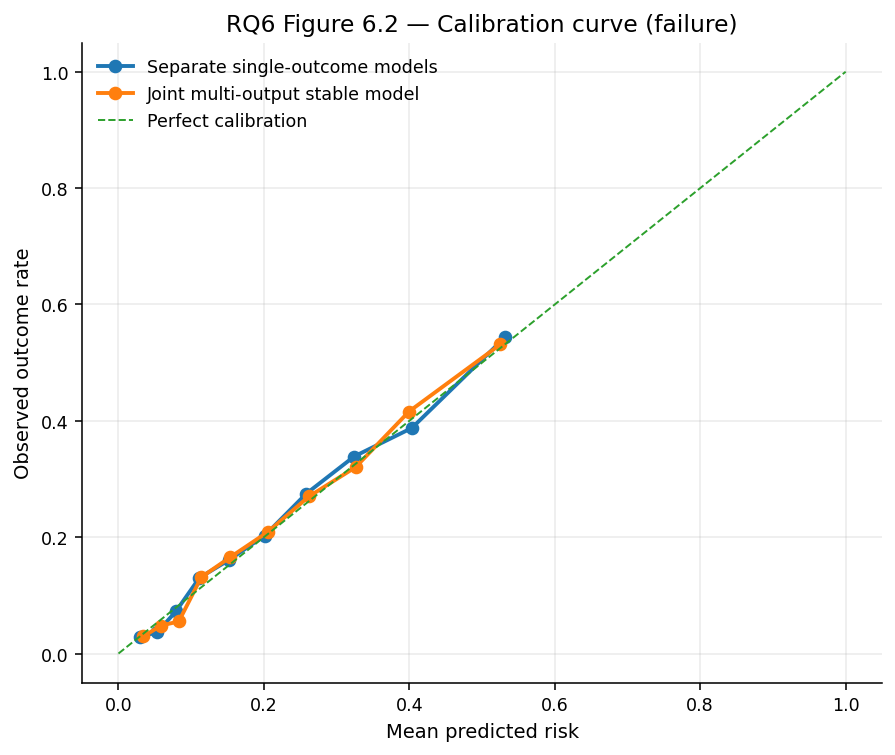

Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_6_7_feature_contributions_by_outcome.csv


,target,feature,importance
29,dropout,days_since_last_activity,0.111375
24,dropout,code_module_GGG,0.018554
50,dropout,max_score,0.017073
74,dropout,weighted_score_sum,0.015619
71,dropout,studied_credits,0.003227
54,dropout,n_assessments_due,0.002915
51,dropout,mean_score,0.002578
0,dropout,active_days,0.002563
19,dropout,code_module_BBB,0.002158
49,dropout,late_rate,0.002022


Saved figure: /kaggle/working/eswa_causal_learning_analytics_outputs/figures_pdf/figure_6_3_shared_vs_specific_contributions.pdf


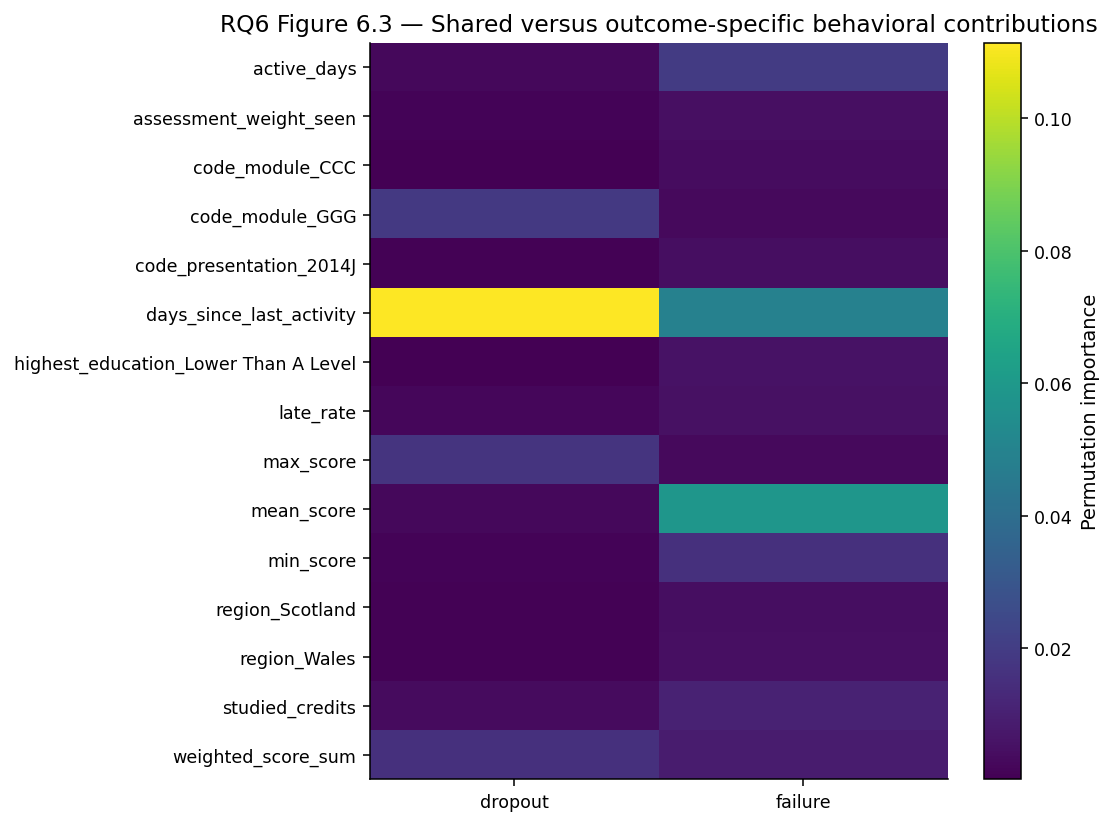

RQ6 interpretation note: use joint modelling primarily for risk-space segmentation and intervention taxonomy. Do not claim AUROC superiority unless Table 6.2 supports it.


In [9]:
# =========================================================
# RQ6. Joint versus separate outcome modelling with bootstrap and calibration
# =========================================================
print('RQ6: evaluating joint versus separate dropout/failure modelling...')

snap = snapshots[max(EARLY_WEEKS)].copy()
tr = snap[snap['student_course_id'].isin(train_ids)].copy()
te = snap[snap['student_course_id'].isin(test_ids)].copy()

Xtr_all = prepare_design_matrix(tr)
Xte_all = prepare_design_matrix(te, fit_columns=Xtr_all.columns)
cols = [c for c in stable_cols if c in Xtr_all.columns]

Xtr = Xtr_all[cols]
Xte = Xte_all[cols]
Ytr = tr[['dropout', 'failure']].astype(int).values
Yte = te[['dropout', 'failure']].astype(int).values

sep_probs = []
sep_metrics = []
sep_models = {}

for j, target in enumerate(['dropout', 'failure']):
    m = make_model('HistGradientBoosting', MAIN_SEED + j)
    m.fit(Xtr, Ytr[:, j])
    p = m.predict_proba(Xte)[:, 1]
    sep_probs.append(p)
    sep_models[target] = m
    sep_metrics.append({
        'approach': 'Separate single-outcome models',
        'target': target,
        **classification_metrics(Yte[:, j], p)
    })

joint_base = make_model('HistGradientBoosting', MAIN_SEED)
joint = MultiOutputClassifier(joint_base)
joint.fit(Xtr, Ytr)
joint_raw = joint.predict_proba(Xte)
joint_probs = [joint_raw[0][:, 1], joint_raw[1][:, 1]]

joint_metrics = []
for j, target in enumerate(['dropout', 'failure']):
    joint_metrics.append({
        'approach': 'Joint multi-output stable model',
        'target': target,
        **classification_metrics(Yte[:, j], joint_probs[j])
    })

rq6_metrics = pd.DataFrame(sep_metrics + joint_metrics)
save_table(rq6_metrics, 'table_6_1_joint_vs_separate_outcome_metrics')

# Bootstrap paired AUROC difference: joint minus separate.
print("Starting bootstrap...")
boot_rows = []
rng = np.random.default_rng(MAIN_SEED)
for j, target in enumerate(['dropout', 'failure']):
    y = Yte[:, j]
    p_sep = sep_probs[j]
    p_joint = joint_probs[j]

    diffs = []
    n = len(y)
    for _ in range(1000):
        idx = rng.integers(0, n, n)
        if len(np.unique(y[idx])) < 2:
            continue
        diffs.append(roc_auc_score(y[idx], p_joint[idx]) - roc_auc_score(y[idx], p_sep[idx]))

    boot_rows.append({
        'target': target,
        'mean_auc_delta_joint_minus_separate': float(np.mean(diffs)),
        'ci_low': float(np.percentile(diffs, 2.5)),
        'ci_high': float(np.percentile(diffs, 97.5)),
        'p_joint_better': float(np.mean(np.array(diffs) > 0)),
        'interpretation': 'positive delta favors joint model; negative delta favors separate model'
    })

rq6_boot = pd.DataFrame(boot_rows)
save_table(rq6_boot, 'table_6_2_bootstrap_joint_minus_separate_auc_difference')

summary6 = rq6_metrics.groupby('approach').agg(
    mean_AUROC=('AUROC', 'mean'),
    mean_AUPRC=('AUPRC', 'mean'),
    mean_ECE=('ECE', 'mean'),
    mean_Brier=('Brier', 'mean'),
    mean_F1=('F1', 'mean')
).reset_index()

if 'cf_quality' in globals() and not cf_quality.empty:
    summary6['empirical_recourse_validity_reference'] = cf_quality['validity'].mean()
else:
    summary6['empirical_recourse_validity_reference'] = np.nan

save_table(summary6, 'table_6_3_joint_vs_separate_summary')

# Joint risk segmentation.
joint_space = pd.DataFrame({
    'student_course_id': te['student_course_id'].values,
    'dropout_true': Yte[:, 0],
    'failure_true': Yte[:, 1],
    'dropout_risk': joint_probs[0],
    'failure_risk': joint_probs[1]
})

def segment(d, f):
    if d >= 0.5 and f >= 0.5:
        return 'High dropout / High failure'
    if d >= 0.5 and f < 0.5:
        return 'High dropout / Low failure'
    if d < 0.5 and f >= 0.5:
        return 'Low dropout / High failure'
    return 'Low dropout / Low failure'

joint_space['risk_segment'] = [
    segment(d, f) for d, f in zip(joint_space['dropout_risk'], joint_space['failure_risk'])
]
joint_space['any_risk_true'] = (
    (joint_space['dropout_true'] == 1) | (joint_space['failure_true'] == 1)
).astype(int)

seg_table = joint_space.groupby('risk_segment').agg(
    n_students=('student_course_id', 'size'),
    mean_dropout_risk=('dropout_risk', 'mean'),
    mean_failure_risk=('failure_risk', 'mean'),
    observed_any_risk_rate=('any_risk_true', 'mean'),
    observed_dropout_rate=('dropout_true', 'mean'),
    observed_failure_rate=('failure_true', 'mean')
).reset_index()

seg_table['recommended_action'] = seg_table['risk_segment'].map({
    'High dropout / High failure': 'high-priority advising plus academic support',
    'High dropout / Low failure': 'retention coaching and engagement outreach',
    'Low dropout / High failure': 'academic tutoring and assessment support',
    'Low dropout / Low failure': 'routine monitoring'
})

save_table(joint_space, 'table_6_4_joint_risk_space_student_level')
save_table(seg_table, 'table_6_5_intervention_strategies_by_joint_risk_segment')

fig, ax = plt.subplots(figsize=(7, 6))
for seg_name, d in joint_space.groupby('risk_segment'):
    ax.scatter(d['dropout_risk'], d['failure_risk'], s=18, alpha=0.65, label=seg_name)
ax.axvline(0.5, linestyle='--', linewidth=1)
ax.axhline(0.5, linestyle='--', linewidth=1)
ax.set_xlabel('Predicted dropout risk')
ax.set_ylabel('Predicted failure risk')
ax.set_title('RQ6 Figure 6.1 — Joint dropout-failure risk space')
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8, loc='upper left')
save_fig(fig, 'figure_6_1_joint_dropout_failure_risk_space')

# Calibration curves.
cal_rows = []
for approach, probs in [
    ('Separate single-outcome models', sep_probs),
    ('Joint multi-output stable model', joint_probs)
]:
    for j, target in enumerate(['dropout', 'failure']):
        y = Yte[:, j]
        p = probs[j]
        bins = pd.qcut(pd.Series(p).rank(method='first'), q=10, duplicates='drop')
        temp = pd.DataFrame({'y': y, 'p': p, 'bin': bins})
        c = temp.groupby('bin').agg(
            mean_predicted_risk=('p', 'mean'),
            observed_rate=('y', 'mean'),
            n=('y', 'size')
        ).reset_index(drop=True)
        c['approach'] = approach
        c['target'] = target
        cal_rows.append(c)

calibration_df = pd.concat(cal_rows, ignore_index=True)
save_table(calibration_df, 'table_6_6_calibration_curve_points')

for target in ['dropout', 'failure']:
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    for approach in calibration_df['approach'].unique():
        d = calibration_df[
            (calibration_df['target'] == target) &
            (calibration_df['approach'] == approach)
        ]
        ax.plot(d['mean_predicted_risk'], d['observed_rate'], marker='o', linewidth=2, label=approach)
    ax.plot([0, 1], [0, 1], linestyle='--', linewidth=1, label='Perfect calibration')
    ax.set_xlabel('Mean predicted risk')
    ax.set_ylabel('Observed outcome rate')
    ax.set_title(f'RQ6 Figure 6.2 — Calibration curve ({target})')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    save_fig(fig, f'figure_6_2_calibration_curve_{target}')

# Permutation feature contribution heatmap.
imp_rows = []
for target, model in sep_models.items():
    y = Yte[:, 0 if target == 'dropout' else 1]
    if len(np.unique(y)) > 1:
        perm = permutation_importance(
            model, Xte, y, scoring='roc_auc',
            n_repeats=8, random_state=MAIN_SEED, n_jobs=-1
        )
        for feat, val in zip(Xte.columns, perm.importances_mean):
            imp_rows.append({'target': target, 'feature': feat, 'importance': val})

imp_df = pd.DataFrame(imp_rows)
save_table(
    imp_df.sort_values(['target', 'importance'], ascending=[True, False]),
    'table_6_7_feature_contributions_by_outcome'
)

if not imp_df.empty:
    top_feats = imp_df.groupby('feature')['importance'].mean().sort_values(ascending=False).head(15).index
    p = imp_df[imp_df['feature'].isin(top_feats)].pivot_table(
        index='feature', columns='target', values='importance', fill_value=0
    )
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(p.values, aspect='auto')
    ax.set_xticks(range(len(p.columns)))
    ax.set_xticklabels(p.columns)
    ax.set_yticks(range(len(p.index)))
    ax.set_yticklabels(p.index)
    fig.colorbar(im, ax=ax, label='Permutation importance')
    ax.set_title('RQ6 Figure 6.3 — Shared versus outcome-specific behavioral contributions')
    save_fig(fig, 'figure_6_3_shared_vs_specific_contributions')

print(
    'RQ6 interpretation note: use joint modelling primarily for risk-space segmentation '
    'and intervention taxonomy. Do not claim AUROC superiority unless Table 6.2 supports it.'
)

RQ7: decision-support simulation with true labels, expected benefit, and subgroup audit...
Any-risk model trained. Test records: 8,149
Spearman correlation between risk and causal-actionable score: 0.9721
Global mean recourse reduction from RQ4: 0.2263
Global recourse validity from RQ4: 0.7600
Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_7_0_student_level_decision_scores.csv


,row_index,student_course_id,true_any_risk,risk_probability,student_level_recourse_reduction,student_level_recourse_valid,student_level_recourse_effort,risk_decile,expected_recourse_reduction,empirical_actionability,expected_intervention_benefit,expected_intervention_benefit_norm,causal_actionable_score
0,0,28400_AAA_2013J,0,0.157308,0.226321,0.76,1.0,2,0.226321,0.38,0.013529,0.069624,0.113466
1,1,30268_AAA_2013J,1,0.996022,0.200742,1.00,1.0,8,0.200742,0.50,0.099972,0.514492,0.755257
2,2,38053_AAA_2013J,0,0.150897,0.226321,0.76,1.0,2,0.226321,0.38,0.012977,0.066787,0.108842
3,3,45462_AAA_2013J,0,0.211019,0.226321,0.76,1.0,2,0.226321,0.38,0.018148,0.093397,0.152208
4,4,52130_AAA_2013J,0,0.107226,0.226321,0.76,1.0,1,0.226321,0.38,0.009222,0.047458,0.077342
5,5,57506_AAA_2013J,0,0.096836,0.226321,0.76,1.0,1,0.226321,0.38,0.008328,0.042860,0.069848
6,6,59185_AAA_2013J,0,0.123001,0.226321,0.76,1.0,1,0.226321,0.38,0.010578,0.054440,0.088721
7,7,63400_AAA_2013J,0,0.215454,0.226321,0.76,1.0,2,0.226321,0.38,0.018530,0.095360,0.155407
8,8,75091_AAA_2013J,0,0.129111,0.226321,0.76,1.0,1,0.226321,0.38,0.011104,0.057144,0.093127
9,9,101781_AAA_2013J,0,0.082275,0.226321,0.76,1.0,0,0.226321,0.38,0.007076,0.036415,0.059345


Test set: 8,149 records
True at-risk cases: 4,302 (52.79%)
Capacities: [25, 50, 81, 100, 162, 200, 407, 500, 814, 1629, 2444, 4074, 8149]
Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_7_1_capacity_constrained_ground_truth_triage.csv


,policy,capacity_absolute,capacity_pct_of_test,students_contacted,n_test_at_risk,true_at_risk_reached,false_alerts,precision,recall,estimated_advisor_hours,net_utility,expected_total_intervention_benefit,expected_mean_intervention_benefit
0,Probability-only ranking,25,0.003068,25,4302,25,0,1.000000,0.005811,4.25,1.000000,2.160171,0.086407
1,Causal-actionable ranking,25,0.003068,25,4302,23,2,0.920000,0.005346,4.25,0.880000,3.954773,0.158191
2,Probability-only ranking,50,0.006136,50,4302,50,0,1.000000,0.011623,8.50,1.000000,4.523401,0.090468
3,Causal-actionable ranking,50,0.006136,50,4302,47,3,0.940000,0.010925,8.50,0.910000,7.463405,0.149268
4,Probability-only ranking,81,0.009940,81,4302,81,0,1.000000,0.018828,13.77,1.000000,7.711052,0.095198
5,Causal-actionable ranking,81,0.009940,81,4302,77,4,0.950617,0.017899,13.77,0.925926,11.836881,0.146134
6,Probability-only ranking,100,0.012271,100,4302,100,0,1.000000,0.023245,17.00,1.000000,9.356198,0.093562
7,Causal-actionable ranking,100,0.012271,100,4302,96,4,0.960000,0.022315,17.00,0.940000,14.502916,0.145029
8,Probability-only ranking,162,0.019880,162,4302,162,0,1.000000,0.037657,27.54,1.000000,15.562682,0.096066
9,Causal-actionable ranking,162,0.019880,162,4302,154,8,0.950617,0.035797,27.54,0.925926,23.039512,0.142219


Running fast bootstrap policy comparison...
Bootstrap capacity 1/13: cap=25
Bootstrap capacity 2/13: cap=50
Bootstrap capacity 3/13: cap=81
Bootstrap capacity 4/13: cap=100
Bootstrap capacity 5/13: cap=162
Bootstrap capacity 6/13: cap=200
Bootstrap capacity 7/13: cap=407
Bootstrap capacity 8/13: cap=500
Bootstrap capacity 9/13: cap=814
Bootstrap capacity 10/13: cap=1629
Bootstrap capacity 11/13: cap=2444
Bootstrap capacity 12/13: cap=4074
Bootstrap capacity 13/13: cap=8149
Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_7_1b_bootstrap_policy_difference.csv


,capacity_absolute,metric,mean_difference_actionable_minus_probability,ci_low,ci_high,p_actionable_better,n_boot
0,25,precision,-0.078400,-0.200000,0.000000,0.0,200
1,25,recall,-0.000487,-0.001162,0.000000,0.0,200
2,25,net_utility,-0.129900,-0.300000,0.000000,0.0,200
3,25,expected_total_intervention_benefit,1.800150,1.468113,2.228557,1.0,200
4,50,precision,-0.055800,-0.120000,0.000000,0.0,200
5,50,recall,-0.000739,-0.001627,-0.000227,0.0,200
6,50,net_utility,-0.088500,-0.210000,0.000000,0.0,200
7,50,expected_total_intervention_benefit,2.906799,2.503063,3.421689,1.0,200
8,81,precision,-0.047963,-0.098765,-0.012346,0.0,200
9,81,recall,-0.000903,-0.001860,-0.000232,0.0,200


Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_7_1c_precision_at_fixed_recall_policy_comparison.csv


,policy,target_recall,actual_recall,precision_at_recall,k_students_contacted,capacity_pct,expected_total_intervention_benefit
0,Probability-only ranking,0.1,0.100186,1.000000,431,0.052890,41.676713
1,Probability-only ranking,0.2,0.200139,1.000000,861,0.105657,85.084631
2,Probability-only ranking,0.3,0.300093,1.000000,1291,0.158424,127.360137
3,Probability-only ranking,0.5,0.500000,0.999071,2153,0.264204,210.046882
4,Probability-only ranking,0.7,0.700139,0.958015,3144,0.385814,325.463900
5,Causal-actionable ranking,0.1,0.100186,0.951435,453,0.055590,57.756855
6,Causal-actionable ranking,0.2,0.200139,0.975085,883,0.108357,101.985494
7,Causal-actionable ranking,0.3,0.300093,0.982496,1314,0.161247,146.369922
8,Causal-actionable ranking,0.5,0.500000,0.983539,2187,0.268376,234.493855
9,Causal-actionable ranking,0.7,0.700139,0.945980,3184,0.390723,340.289689


Saved figure: /kaggle/working/eswa_causal_learning_analytics_outputs/figures_pdf/figure_7_1_workload_precision_recall_expected_benefit.pdf


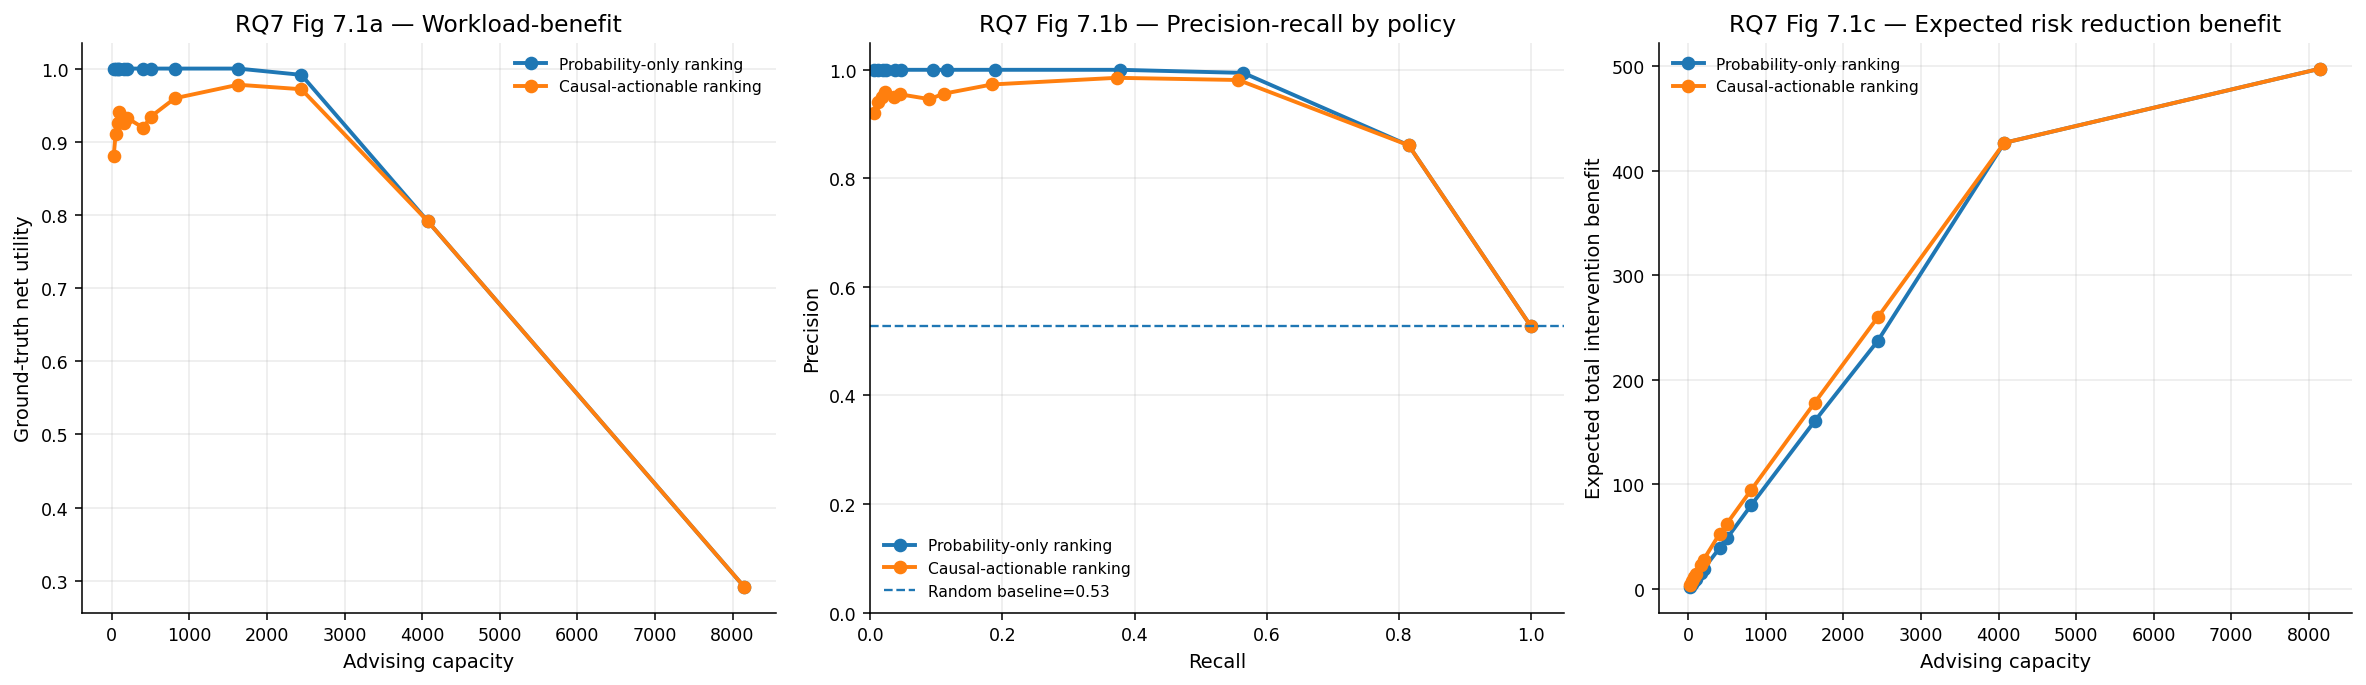

Saved figure: /kaggle/working/eswa_causal_learning_analytics_outputs/figures_pdf/figure_7_2_institutional_decision_support_pipeline.pdf


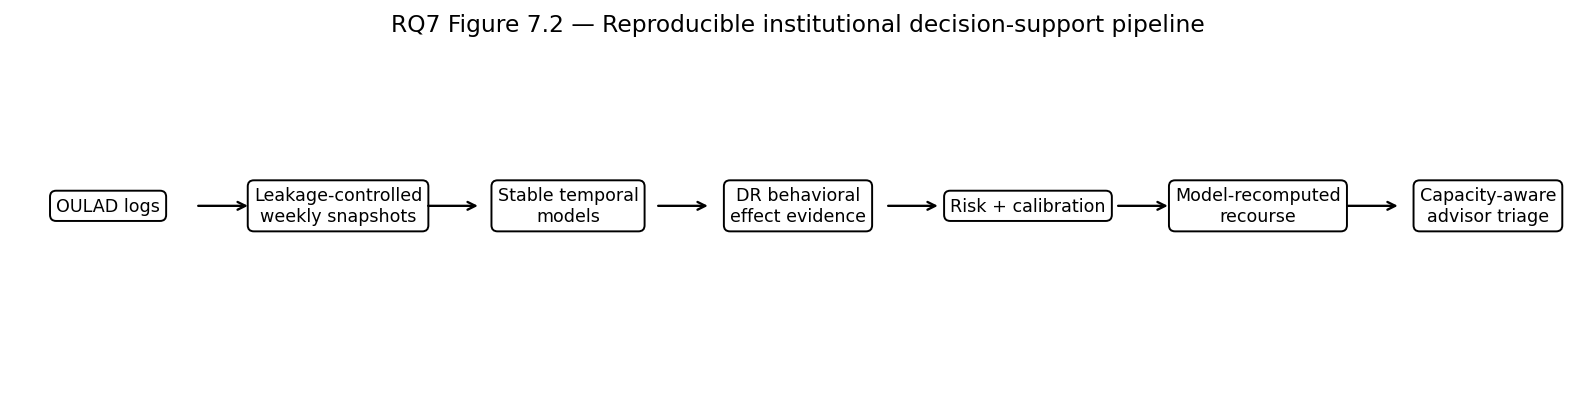

Subgroup audit threshold: top 30% by causal-actionable score
Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_7_2_real_subgroup_fairness_actionability_audit.csv


,attribute,group,n,alerts,true_alerts,observed_risk_rate,alert_rate_operating_threshold,alert_precision,alert_precision_ci_low,alert_precision_ci_high,mean_predicted_risk,mean_expected_intervention_benefit,precision_gap_vs_global_operating_threshold,flag
0,gender,F,3660,1072,1051,0.521038,0.292896,0.980410,0.970238,0.987152,0.527583,0.059934,-0.000776,within monitoring tolerance
1,gender,M,4489,1373,1348,0.533526,0.305859,0.981792,0.973258,0.987637,0.537072,0.062041,0.000606,within monitoring tolerance
2,age_band,0-35,5752,1861,1827,0.556676,0.323540,0.981730,0.974579,0.986897,0.558458,0.064575,0.000544,within monitoring tolerance
3,age_band,35-55,2334,572,560,0.461440,0.245073,0.979021,0.963691,0.987959,0.473913,0.053071,-0.002165,within monitoring tolerance
4,age_band,55<=,63,12,12,0.365079,0.190476,1.000000,0.757499,1.000000,0.373119,0.040596,0.018814,within monitoring tolerance
5,disability,N,7343,2155,2115,0.516955,0.293477,0.981439,0.974824,0.986339,0.522809,0.059846,0.000252,within monitoring tolerance
6,disability,Y,806,290,284,0.627792,0.359801,0.979310,0.955604,0.990484,0.623925,0.072473,-0.001876,within monitoring tolerance
7,region,East Anglian Region,852,266,260,0.525822,0.312207,0.977444,0.951671,0.989622,0.534654,0.061215,-0.003742,within monitoring tolerance
8,region,East Midlands Region,608,183,180,0.523026,0.300987,0.983607,0.952917,0.994409,0.526653,0.058604,0.002420,within monitoring tolerance
9,region,Ireland,290,64,62,0.482759,0.220690,0.968750,0.893025,0.991388,0.491223,0.061166,-0.012436,within monitoring tolerance


Saved figure: /kaggle/working/eswa_causal_learning_analytics_outputs/figures_pdf/figure_7_3_real_subgroup_alert_precision_audit.pdf


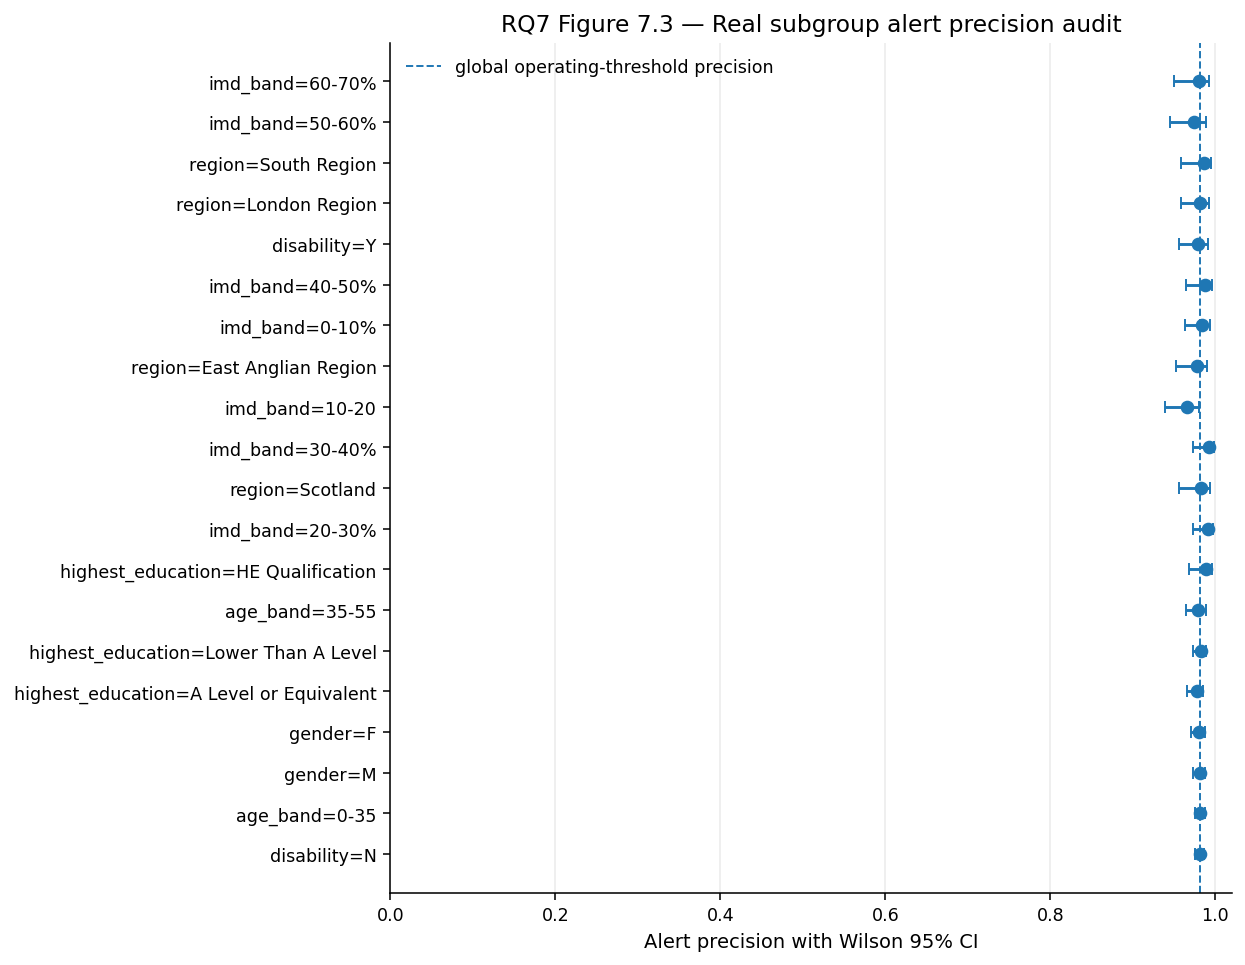

RQ7 completed successfully.


In [10]:
# =========================================================
# RQ7. Capacity-aware decision support with student-level expected intervention benefit
# Standalone-safe version: does NOT require train_eval_for_week()
# =========================================================
print("RQ7: decision-support simulation with true labels, expected benefit, and subgroup audit...")

# ---------------------------------------------------------
# 0. Safety checks
# ---------------------------------------------------------
required_globals = [
    "snapshots", "EARLY_WEEKS", "train_ids", "test_ids",
    "stable_cols", "prepare_design_matrix", "make_model",
    "MAIN_SEED", "save_table", "save_fig"
]

missing = [g for g in required_globals if g not in globals()]
if missing:
    raise NameError(
        f"Missing required objects from earlier cells: {missing}. "
        "Run Setup → Data loading → Model helpers → RQ1 before RQ7."
    )

if "TOPK_CAPACITIES" not in globals():
    TOPK_CAPACITIES = [25, 50, 100, 200, 500]

RQ7_N_BOOT = 200
RQ7_SUBGROUP_ALERT_QUANTILE = 0.70

# ---------------------------------------------------------
# 1. Train any-risk model directly
# ---------------------------------------------------------
wk = max(EARLY_WEEKS)
snap = snapshots[wk].copy()

tr = snap[snap["student_course_id"].isin(train_ids)].copy()
te_any = snap[snap["student_course_id"].isin(test_ids)].copy().reset_index(drop=True)

Xtr_all = prepare_design_matrix(tr)
Xte_all = prepare_design_matrix(te_any, fit_columns=Xtr_all.columns)

cols = [c for c in stable_cols if c in Xtr_all.columns]
if len(cols) < 2:
    print("Warning: stable_cols has too few usable columns. Falling back to all features.")
    cols = list(Xtr_all.columns)

Xtr_any = Xtr_all[cols].copy()
Xte_any = Xte_all[cols].copy()

ytr_any = tr["any_risk"].astype(int).values
yte_any = te_any["any_risk"].astype(int).values

if len(np.unique(ytr_any)) < 2:
    raise ValueError("Training target any_risk has only one class.")
if len(np.unique(yte_any)) < 2:
    raise ValueError("Test target any_risk has only one class.")

model_any = make_model("HistGradientBoosting", MAIN_SEED)
model_any.fit(Xtr_any, ytr_any)
prob_any = model_any.predict_proba(Xte_any)[:, 1]

print(f"Any-risk model trained. Test records: {len(te_any):,}")

# ---------------------------------------------------------
# 2. Student-level decision scores
# ---------------------------------------------------------
decision_df = pd.DataFrame({
    "row_index": np.arange(len(te_any)),
    "student_course_id": te_any["student_course_id"].values,
    "true_any_risk": yte_any,
    "risk_probability": prob_any
})

decision_df["student_level_recourse_reduction"] = np.nan
decision_df["student_level_recourse_valid"] = np.nan
decision_df["student_level_recourse_effort"] = np.nan

# ---------------------------------------------------------
# 2a. Student-level recourse benefit from RQ4
# ---------------------------------------------------------
global_mean_reduction = 0.0
global_validity = 0.0
global_median_effort = 1.0

if "cf_all" in globals() and isinstance(cf_all, pd.DataFrame) and not cf_all.empty:
    cf_tmp = cf_all.copy()

    if "risk_reduction" in cf_tmp.columns:
        cf_tmp["risk_reduction"] = (
            pd.to_numeric(cf_tmp["risk_reduction"], errors="coerce")
            .clip(lower=0)
        )
        global_mean_reduction = float(cf_tmp["risk_reduction"].dropna().mean())
        if not np.isfinite(global_mean_reduction):
            global_mean_reduction = 0.0

    if "effort" in cf_tmp.columns:
        cf_tmp["effort"] = pd.to_numeric(cf_tmp["effort"], errors="coerce")
        global_median_effort = float(cf_tmp["effort"].dropna().median())
        if not np.isfinite(global_median_effort):
            global_median_effort = 1.0
    else:
        cf_tmp["effort"] = np.nan

    if "valid" in cf_tmp.columns:
        if cf_tmp["valid"].dtype == bool:
            cf_tmp["valid_numeric"] = cf_tmp["valid"].astype(float)
        else:
            cf_tmp["valid_numeric"] = (
                cf_tmp["valid"]
                .astype(str)
                .str.lower()
                .map({"true": 1.0, "1": 1.0, "yes": 1.0, "false": 0.0, "0": 0.0, "no": 0.0})
            )
            cf_tmp["valid_numeric"] = cf_tmp["valid_numeric"].fillna(
                pd.to_numeric(cf_tmp["valid"], errors="coerce")
            )
        global_validity = float(cf_tmp["valid_numeric"].dropna().mean())
        if not np.isfinite(global_validity):
            global_validity = 0.0
    else:
        cf_tmp["valid_numeric"] = 1.0
        global_validity = 1.0

    required_recourse_cols = {"risk_reduction", "valid_numeric", "effort"}

    if required_recourse_cols.issubset(set(cf_tmp.columns)):
        if "row_index" in cf_tmp.columns:
            recourse_by_row = cf_tmp.groupby("row_index").agg(
                student_level_recourse_reduction=("risk_reduction", "max"),
                student_level_recourse_valid=("valid_numeric", "max"),
                student_level_recourse_effort=("effort", "median")
            ).reset_index()

            decision_df = decision_df.merge(
                recourse_by_row,
                on="row_index",
                how="left",
                suffixes=("", "_rq4")
            )

            for c in [
                "student_level_recourse_reduction",
                "student_level_recourse_valid",
                "student_level_recourse_effort"
            ]:
                rq4_c = f"{c}_rq4"
                if rq4_c in decision_df.columns:
                    decision_df[c] = decision_df[rq4_c].combine_first(decision_df[c])
                    decision_df.drop(columns=[rq4_c], inplace=True)

        elif "student_course_id" in cf_tmp.columns:
            recourse_by_student = cf_tmp.groupby("student_course_id").agg(
                student_level_recourse_reduction=("risk_reduction", "max"),
                student_level_recourse_valid=("valid_numeric", "max"),
                student_level_recourse_effort=("effort", "median")
            ).reset_index()

            decision_df = decision_df.merge(
                recourse_by_student,
                on="student_course_id",
                how="left",
                suffixes=("", "_rq4")
            )

            for c in [
                "student_level_recourse_reduction",
                "student_level_recourse_valid",
                "student_level_recourse_effort"
            ]:
                rq4_c = f"{c}_rq4"
                if rq4_c in decision_df.columns:
                    decision_df[c] = decision_df[rq4_c].combine_first(decision_df[c])
                    decision_df.drop(columns=[rq4_c], inplace=True)
else:
    print("Warning: cf_all is unavailable or empty. RQ7 will run, but expected intervention benefit will be weak.")

# ---------------------------------------------------------
# 2b. Impute missing recourse benefit by risk decile
# ---------------------------------------------------------
decision_df["risk_decile"] = pd.qcut(
    decision_df["risk_probability"].rank(method="first"),
    q=min(10, len(decision_df)),
    labels=False,
    duplicates="drop"
)

decile_reduction = decision_df.groupby("risk_decile")["student_level_recourse_reduction"].transform("median")
decision_df["student_level_recourse_reduction"] = (
    decision_df["student_level_recourse_reduction"]
    .fillna(decile_reduction)
    .fillna(global_mean_reduction)
    .fillna(0.0)
)

decile_valid = decision_df.groupby("risk_decile")["student_level_recourse_valid"].transform("median")
decision_df["student_level_recourse_valid"] = (
    decision_df["student_level_recourse_valid"]
    .fillna(decile_valid)
    .fillna(global_validity)
    .fillna(0.0)
)

decile_effort = decision_df.groupby("risk_decile")["student_level_recourse_effort"].transform("median")
decision_df["student_level_recourse_effort"] = (
    decision_df["student_level_recourse_effort"]
    .fillna(decile_effort)
    .fillna(global_median_effort)
    .fillna(1.0)
)

decision_df["student_level_recourse_reduction"] = (
    pd.to_numeric(decision_df["student_level_recourse_reduction"], errors="coerce")
    .fillna(0.0)
    .clip(lower=0)
)

decision_df["student_level_recourse_valid"] = (
    pd.to_numeric(decision_df["student_level_recourse_valid"], errors="coerce")
    .fillna(0.0)
    .clip(lower=0, upper=1)
)

decision_df["student_level_recourse_effort"] = (
    pd.to_numeric(decision_df["student_level_recourse_effort"], errors="coerce")
    .fillna(1.0)
    .clip(lower=0.05)
)

decision_df["expected_recourse_reduction"] = decision_df["student_level_recourse_reduction"]

decision_df["empirical_actionability"] = (
    decision_df["student_level_recourse_valid"] /
    (1.0 + decision_df["student_level_recourse_effort"])
)

decision_df["expected_intervention_benefit"] = (
    decision_df["risk_probability"]
    * decision_df["expected_recourse_reduction"]
    * decision_df["empirical_actionability"]
)

benefit_max = decision_df["expected_intervention_benefit"].max()

if np.isfinite(benefit_max) and benefit_max > 0:
    decision_df["expected_intervention_benefit_norm"] = (
        decision_df["expected_intervention_benefit"] / benefit_max
    )
else:
    decision_df["expected_intervention_benefit_norm"] = 0.0
    print("Warning: expected intervention benefit is zero for all students. Check whether RQ4 ran successfully.")

decision_df["causal_actionable_score"] = (
    0.50 * decision_df["risk_probability"]
    + 0.50 * decision_df["expected_intervention_benefit_norm"]
)

rank_corr = decision_df[["risk_probability", "causal_actionable_score"]].corr(method="spearman").iloc[0, 1]

print(f"Spearman correlation between risk and causal-actionable score: {rank_corr:.4f}")
print(f"Global mean recourse reduction from RQ4: {global_mean_reduction:.4f}")
print(f"Global recourse validity from RQ4: {global_validity:.4f}")

save_table(decision_df, "table_7_0_student_level_decision_scores")

n_test_total = len(decision_df)
n_test_at_risk = int(decision_df["true_any_risk"].sum())
base_rate = n_test_at_risk / max(1, n_test_total)

print(f"Test set: {n_test_total:,} records")
print(f"True at-risk cases: {n_test_at_risk:,} ({base_rate:.2%})")

# ---------------------------------------------------------
# 3. Capacity-constrained triage
# ---------------------------------------------------------
relative_fracs = [0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50, 1.00]
relative_caps = [max(1, int(f * n_test_total)) for f in relative_fracs]
absolute_caps = [min(c, n_test_total) for c in TOPK_CAPACITIES]
all_caps = sorted(set(relative_caps + absolute_caps))

print("Capacities:", all_caps)

triage_rows = []

for cap in all_caps:
    for policy, score_col in [
        ("Probability-only ranking", "risk_probability"),
        ("Causal-actionable ranking", "causal_actionable_score")
    ]:
        d = decision_df.sort_values(score_col, ascending=False).head(cap)
        contacted = len(d)
        tp = int(d["true_any_risk"].sum())
        fp = contacted - tp

        precision = tp / max(1, contacted)
        recall = tp / max(1, n_test_at_risk)
        net_utility = (tp - 0.5 * fp) / max(1, contacted)

        triage_rows.append({
            "policy": policy,
            "capacity_absolute": cap,
            "capacity_pct_of_test": contacted / max(1, n_test_total),
            "students_contacted": contacted,
            "n_test_at_risk": n_test_at_risk,
            "true_at_risk_reached": tp,
            "false_alerts": fp,
            "precision": precision,
            "recall": recall,
            "estimated_advisor_hours": contacted * 0.17,
            "net_utility": net_utility,
            "expected_total_intervention_benefit": float(d["expected_intervention_benefit"].sum()),
            "expected_mean_intervention_benefit": float(d["expected_intervention_benefit"].mean())
        })

triage_df = pd.DataFrame(triage_rows)
save_table(triage_df, "table_7_1_capacity_constrained_ground_truth_triage")

# ---------------------------------------------------------
# 4. Fast bootstrap policy difference
# ---------------------------------------------------------
print("Running fast bootstrap policy comparison...")

boot_rows = []
rng = np.random.default_rng(MAIN_SEED)

for cap_i, cap in enumerate(all_caps, start=1):
    print(f"Bootstrap capacity {cap_i}/{len(all_caps)}: cap={cap}")

    prob_rank = decision_df.sort_values("risk_probability", ascending=False).head(cap).reset_index(drop=True)
    act_rank = decision_df.sort_values("causal_actionable_score", ascending=False).head(cap).reset_index(drop=True)

    p_y = prob_rank["true_any_risk"].to_numpy()
    a_y = act_rank["true_any_risk"].to_numpy()
    p_b = prob_rank["expected_intervention_benefit"].to_numpy()
    a_b = act_rank["expected_intervention_benefit"].to_numpy()

    n_p = len(p_y)
    n_a = len(a_y)

    for metric in ["precision", "recall", "net_utility", "expected_total_intervention_benefit"]:
        diffs = []

        for _ in range(RQ7_N_BOOT):
            idx_p = rng.integers(0, n_p, n_p)
            idx_a = rng.integers(0, n_a, n_a)

            py = p_y[idx_p]
            ay = a_y[idx_a]
            pb = p_b[idx_p]
            ab = a_b[idx_a]

            if metric == "precision":
                p_val = py.sum() / max(1, n_p)
                a_val = ay.sum() / max(1, n_a)

            elif metric == "recall":
                p_val = py.sum() / max(1, n_test_at_risk)
                a_val = ay.sum() / max(1, n_test_at_risk)

            elif metric == "net_utility":
                p_tp = py.sum()
                a_tp = ay.sum()
                p_fp = n_p - p_tp
                a_fp = n_a - a_tp
                p_val = (p_tp - 0.5 * p_fp) / max(1, n_p)
                a_val = (a_tp - 0.5 * a_fp) / max(1, n_a)

            elif metric == "expected_total_intervention_benefit":
                p_val = pb.sum()
                a_val = ab.sum()

            diffs.append(a_val - p_val)

        diffs = np.asarray(diffs, dtype=float)

        boot_rows.append({
            "capacity_absolute": cap,
            "metric": metric,
            "mean_difference_actionable_minus_probability": float(np.nanmean(diffs)),
            "ci_low": float(np.nanpercentile(diffs, 2.5)),
            "ci_high": float(np.nanpercentile(diffs, 97.5)),
            "p_actionable_better": float(np.nanmean(diffs > 0)),
            "n_boot": RQ7_N_BOOT
        })

policy_boot_df = pd.DataFrame(boot_rows)
save_table(policy_boot_df, "table_7_1b_bootstrap_policy_difference")

# ---------------------------------------------------------
# 5. Precision at fixed recall
# ---------------------------------------------------------
recall_levels = [0.10, 0.20, 0.30, 0.50, 0.70]
prec_recall_rows = []

for policy, score_col in [
    ("Probability-only ranking", "risk_probability"),
    ("Causal-actionable ranking", "causal_actionable_score")
]:
    ranked = decision_df.sort_values(score_col, ascending=False).reset_index(drop=True)
    cum_tp = ranked["true_any_risk"].cumsum().values

    for target_recall in recall_levels:
        needed_tp = target_recall * n_test_at_risk
        k_idx = np.searchsorted(cum_tp, needed_tp)
        k_idx = min(k_idx, len(ranked) - 1)
        k = k_idx + 1

        tp = int(cum_tp[k_idx])
        precision = tp / max(1, k)
        actual_recall = tp / max(1, n_test_at_risk)

        prec_recall_rows.append({
            "policy": policy,
            "target_recall": target_recall,
            "actual_recall": actual_recall,
            "precision_at_recall": precision,
            "k_students_contacted": k,
            "capacity_pct": k / max(1, n_test_total),
            "expected_total_intervention_benefit": float(
                ranked.head(k)["expected_intervention_benefit"].sum()
            )
        })

prec_recall_df = pd.DataFrame(prec_recall_rows)
save_table(prec_recall_df, "table_7_1c_precision_at_fixed_recall_policy_comparison")

# ---------------------------------------------------------
# 6. Figure 7.1
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 5.0))

ax = axes[0]
for policy in triage_df["policy"].unique():
    d = triage_df[triage_df["policy"] == policy].sort_values("capacity_absolute")
    ax.plot(d["capacity_absolute"], d["net_utility"], marker="o", linewidth=2, label=policy)
ax.set_xlabel("Advising capacity")
ax.set_ylabel("Ground-truth net utility")
ax.set_title("RQ7 Fig 7.1a — Workload-benefit")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
for policy in triage_df["policy"].unique():
    d = triage_df[triage_df["policy"] == policy].sort_values("recall")
    ax.plot(d["recall"], d["precision"], marker="o", linewidth=2, label=policy)
ax.axhline(base_rate, linestyle="--", linewidth=1.2, label=f"Random baseline={base_rate:.2f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("RQ7 Fig 7.1b — Precision-recall by policy")
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)

ax = axes[2]
for policy in triage_df["policy"].unique():
    d = triage_df[triage_df["policy"] == policy].sort_values("capacity_absolute")
    ax.plot(
        d["capacity_absolute"],
        d["expected_total_intervention_benefit"],
        marker="o",
        linewidth=2,
        label=policy
    )
ax.set_xlabel("Advising capacity")
ax.set_ylabel("Expected total intervention benefit")
ax.set_title("RQ7 Fig 7.1c — Expected risk reduction benefit")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)

save_fig(fig, "figure_7_1_workload_precision_recall_expected_benefit")

# ---------------------------------------------------------
# 7. Figure 7.2 pipeline
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(11.5, 3.0))
ax.axis("off")

steps = [
    "OULAD logs",
    "Leakage-controlled\nweekly snapshots",
    "Stable temporal\nmodels",
    "DR behavioral\neffect evidence",
    "Risk + calibration",
    "Model-recomputed\nrecourse",
    "Capacity-aware\nadvisor triage"
]

xs = np.linspace(0.06, 0.94, len(steps))

for i, (x, label) in enumerate(zip(xs, steps)):
    ax.text(
        x, 0.55, label,
        ha="center",
        va="center",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="black", lw=1.0)
    )

    if i < len(xs) - 1:
        ax.annotate(
            "",
            xy=(xs[i + 1] - 0.055, 0.55),
            xytext=(x + 0.055, 0.55),
            arrowprops=dict(arrowstyle="->", lw=1.2)
        )

ax.set_title("RQ7 Figure 7.2 — Reproducible institutional decision-support pipeline", pad=12)
save_fig(fig, "figure_7_2_institutional_decision_support_pipeline")

# ---------------------------------------------------------
# 8. Real subgroup fairness audit with Wilson CI
# ---------------------------------------------------------
def wilson_ci(k, n, z=1.96):
    if n <= 0:
        return np.nan, np.nan

    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom

    lo = max(0.0, center - margin)
    hi = min(1.0, center + margin)

    lo = min(lo, p)
    hi = max(hi, p)

    return lo, hi


demo_cols = [
    c for c in ["gender", "age_band", "disability", "region", "highest_education", "imd_band"]
    if c in te_any.columns
]

audit_base = te_any[["student_course_id"] + demo_cols].copy()
audit = decision_df.merge(audit_base, on="student_course_id", how="left")

audit_rows = []

audit_threshold = np.percentile(
    decision_df["causal_actionable_score"],
    100 * RQ7_SUBGROUP_ALERT_QUANTILE
)

print(
    f"Subgroup audit threshold: top {int((1 - RQ7_SUBGROUP_ALERT_QUANTILE) * 100)}% "
    f"by causal-actionable score"
)

for group_col in demo_cols:
    for val, d in audit.groupby(group_col):
        if len(d) < 25:
            continue

        pred_alert = d["causal_actionable_score"] >= audit_threshold
        alerts = int(pred_alert.sum())
        tp = int(((pred_alert) & (d["true_any_risk"] == 1)).sum())

        if alerts == 0:
            continue

        precision = tp / alerts
        lo, hi = wilson_ci(tp, alerts)

        audit_rows.append({
            "attribute": group_col,
            "group": str(val),
            "n": len(d),
            "alerts": alerts,
            "true_alerts": tp,
            "observed_risk_rate": float(d["true_any_risk"].mean()),
            "alert_rate_operating_threshold": float(pred_alert.mean()),
            "alert_precision": float(precision),
            "alert_precision_ci_low": float(lo),
            "alert_precision_ci_high": float(hi),
            "mean_predicted_risk": float(d["risk_probability"].mean()),
            "mean_expected_intervention_benefit": float(
                d["expected_intervention_benefit"].mean()
            )
        })

fairness_df = pd.DataFrame(audit_rows)

if not fairness_df.empty:
    global_alert = decision_df["causal_actionable_score"] >= audit_threshold
    global_precision = float(decision_df.loc[global_alert, "true_any_risk"].mean())

    fairness_df["precision_gap_vs_global_operating_threshold"] = (
        fairness_df["alert_precision"] - global_precision
    )

    fairness_df["flag"] = np.where(
        fairness_df["precision_gap_vs_global_operating_threshold"].abs() > 0.10,
        "review subgroup performance",
        "within monitoring tolerance"
    )
else:
    global_precision = np.nan

save_table(fairness_df, "table_7_2_real_subgroup_fairness_actionability_audit")

# ---------------------------------------------------------
# 9. Figure 7.3 subgroup audit
# ---------------------------------------------------------
if not fairness_df.empty:
    top_plot = fairness_df.sort_values("n", ascending=False).head(20).copy()

    for c in ["alert_precision", "alert_precision_ci_low", "alert_precision_ci_high"]:
        top_plot[c] = pd.to_numeric(top_plot[c], errors="coerce")

    top_plot = top_plot.dropna(
        subset=["alert_precision", "alert_precision_ci_low", "alert_precision_ci_high"]
    ).copy()

    top_plot["alert_precision"] = top_plot["alert_precision"].clip(0, 1)
    top_plot["alert_precision_ci_low"] = top_plot["alert_precision_ci_low"].clip(0, 1)
    top_plot["alert_precision_ci_high"] = top_plot["alert_precision_ci_high"].clip(0, 1)

    top_plot["alert_precision_ci_low"] = np.minimum(
        top_plot["alert_precision_ci_low"],
        top_plot["alert_precision"]
    )

    top_plot["alert_precision_ci_high"] = np.maximum(
        top_plot["alert_precision_ci_high"],
        top_plot["alert_precision"]
    )

    labels = top_plot["attribute"].astype(str) + "=" + top_plot["group"].astype(str)
    y = np.arange(len(top_plot))

    x = top_plot["alert_precision"].to_numpy(dtype=float)

    xerr_low = np.maximum(
        0,
        x - top_plot["alert_precision_ci_low"].to_numpy(dtype=float)
    )

    xerr_high = np.maximum(
        0,
        top_plot["alert_precision_ci_high"].to_numpy(dtype=float) - x
    )

    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(top_plot))))

    ax.errorbar(
        x,
        y,
        xerr=np.vstack([xerr_low, xerr_high]),
        fmt="o",
        capsize=3
    )

    if np.isfinite(global_precision):
        ax.axvline(
            global_precision,
            linestyle="--",
            linewidth=1,
            label="global operating-threshold precision"
        )

    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlim(0, 1.02)
    ax.set_xlabel("Alert precision with Wilson 95% CI")
    ax.set_title("RQ7 Figure 7.3 — Real subgroup alert precision audit")
    ax.legend(frameon=False)
    ax.grid(axis="x", alpha=0.25)

    save_fig(fig, "figure_7_3_real_subgroup_alert_precision_audit")
else:
    print("Fairness audit table is empty; Figure 7.3 was skipped.")

print("RQ7 completed successfully.")

In [11]:
# =========================================================
# 8. Integrated ESWA technical summary, manifest, and output zip
# =========================================================
summary_rows = []


def add_summary(area, evidence, caveat):
    summary_rows.append({
        'area': area,
        'evidence_generated': evidence,
        'remaining_caveat_for_manuscript': caveat
    })


add_summary(
    'RQ1 predictive comparison',
    'Repeated-seed AUROC/AUPRC/F1/ECE/Brier tables, AUROC CIs, weekly AUROC figures, and threshold-optimized failure F1 using out-of-fold training predictions.',
    'Do not claim universal predictive superiority. Safe claim: the stable-causal-temporal model is competitive while enabling later causal-effect and actionability analyses.'
)

add_summary(
    'RQ2 causal-effect evidence',
    'Doubly robust temporally ordered ATE estimates with bootstrap sign stability and a stable behavior-outcome graph.',
    'Causal interpretation is conditional on temporal precedence, observed-confounder exchangeability, overlap, and correct nuisance modelling. Hidden confounding remains possible.'
)

add_summary(
    'RQ3 robustness',
    'Cross-course transfer table, AUROC/ECE/Brier trade-off summary with bootstrap CI, and synthetic shift sensitivity.',
    'Cross-course AUROC transfer is mixed and sometimes negative. Frame RQ3 as an accuracy-calibration robustness trade-off rather than universal transfer improvement.'
)

add_summary(
    'RQ4 counterfactual recourse',
    'Model-recomputed feasible recourse with validity, plausibility, sparsity, effort, and risk reduction.',
    'Counterfactuals are algorithmic model-space recourse, not guaranteed real-world intervention effects. Some high-risk cases may not have sparse valid recourse under the chosen constraints.'
)

add_summary(
    'RQ5 early detection',
    'Weekly readiness metrics, threshold utility surface, and utility sensitivity analysis across multiple TP/FP/FN assumptions.',
    'Utility weights are institutional decision assumptions. Report sensitivity results and avoid claiming one universally optimal intervention week unless stable across scenarios.'
)

add_summary(
    'RQ6 joint modelling',
    'Separate versus joint metrics, bootstrap AUROC difference, calibration curves, risk-space segmentation, and feature contribution heatmap.',
    'If joint AUROC is similar or lower, frame the contribution as intervention taxonomy, calibration, and multi-outcome segmentation rather than predictive superiority.'
)

add_summary(
    'RQ7 decision support',
    'Capacity-aware triage using true labels, student-level expected intervention benefit, bootstrap policy differences, fixed-recall precision, and real subgroup audit with Wilson CIs.',
    'Causal-actionable ranking should be interpreted as intervention-oriented prioritization. It may trade some pure precision at low capacity for greater expected intervention benefit.'
)

summary_df = pd.DataFrame(summary_rows)
save_table(summary_df, 'table_8_1_integrated_eswa_technical_readiness_summary')

# ---------------------------------------------------------
# Output manifest
# ---------------------------------------------------------
manifest = []

for folder, kind in [(FIG_DIR, 'figure_pdf'), (TAB_DIR, 'table_csv'), (ART_DIR, 'artifact')]:
    if folder.exists():
        for p in sorted(folder.glob('*')):
            if p.is_file():
                manifest.append({
                    'kind': kind,
                    'filename': p.name,
                    'relative_path': str(p.relative_to(OUT)),
                    'size_bytes': p.stat().st_size
                })

manifest_df = pd.DataFrame(manifest)
save_table(manifest_df, 'table_8_2_output_manifest')

# ---------------------------------------------------------
# Run metadata
# ---------------------------------------------------------
meta = {
    'dataset_root': str(OULAD_ROOT) if 'OULAD_ROOT' in globals() else 'unknown',
    'early_weeks': EARLY_WEEKS if 'EARLY_WEEKS' in globals() else None,
    'random_seeds': RANDOM_SEEDS if 'RANDOM_SEEDS' in globals() else None,
    'main_seed': MAIN_SEED if 'MAIN_SEED' in globals() else None,
    'has_xgboost': HAS_XGB if 'HAS_XGB' in globals() else None,
    'n_train_student_courses': len(train_ids) if 'train_ids' in globals() else None,
    'n_test_student_courses': len(test_ids) if 'test_ids' in globals() else None,
    'output_dir': str(OUT),
    'technical_note': (
        'This notebook is designed for ESWA-level reproducibility. Claims must follow '
        'the observed evidence: competitive prediction, conditional causal-effect evidence, '
        'model-space recourse, utility-sensitive early detection, joint risk taxonomy, '
        'and capacity-aware decision support.'
    )
}

ART_DIR.mkdir(parents=True, exist_ok=True)

with open(ART_DIR / 'run_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

# ---------------------------------------------------------
# Zip all generated outputs
# ---------------------------------------------------------
zip_path = WORK_DIR / 'eswa_causal_learning_analytics_outputs.zip'

if zip_path.exists():
    zip_path.unlink()

shutil.make_archive(str(zip_path).replace('.zip', ''), 'zip', OUT)

print('\nFinal zipped output:', zip_path)
print('Figures:', len(list(FIG_DIR.glob('*.pdf'))), 'PDFs')
print('Tables:', len(list(TAB_DIR.glob('*.csv'))), 'CSVs')
print('Artifacts:', len(list(ART_DIR.glob('*'))), 'files')

print(
    '\nImportant: inspect table_8_1 before manuscript writing. '
    'It contains the caveats that prevent overclaiming.'
)

Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_8_1_integrated_eswa_technical_readiness_summary.csv


,area,evidence_generated,remaining_caveat_for_manuscript
0,RQ1 predictive comparison,"Repeated-seed AUROC/AUPRC/F1/ECE/Brier tables,...",Do not claim universal predictive superiority....
1,RQ2 causal-effect evidence,Doubly robust temporally ordered ATE estimates...,Causal interpretation is conditional on tempor...
2,RQ3 robustness,"Cross-course transfer table, AUROC/ECE/Brier t...",Cross-course AUROC transfer is mixed and somet...
3,RQ4 counterfactual recourse,Model-recomputed feasible recourse with validi...,Counterfactuals are algorithmic model-space re...
4,RQ5 early detection,"Weekly readiness metrics, threshold utility su...",Utility weights are institutional decision ass...
5,RQ6 joint modelling,"Separate versus joint metrics, bootstrap AUROC...","If joint AUROC is similar or lower, frame the ..."
6,RQ7 decision support,"Capacity-aware triage using true labels, stude...",Causal-actionable ranking should be interprete...


Saved table: /kaggle/working/eswa_causal_learning_analytics_outputs/tables_csv/table_8_2_output_manifest.csv


,kind,filename,relative_path,size_bytes
0,figure_pdf,figure_1_1_early_week_auroc_dropout.pdf,figures_pdf/figure_1_1_early_week_auroc_dropou...,16880
1,figure_pdf,figure_1_1_early_week_auroc_failure.pdf,figures_pdf/figure_1_1_early_week_auroc_failur...,17615
2,figure_pdf,figure_1_2_failure_f1_default_vs_optimized_thr...,figures_pdf/figure_1_2_failure_f1_default_vs_o...,19814
3,figure_pdf,figure_2_1_dr_effect_forest_dropout.pdf,figures_pdf/figure_2_1_dr_effect_forest_dropou...,13636
4,figure_pdf,figure_2_1_dr_effect_forest_failure.pdf,figures_pdf/figure_2_1_dr_effect_forest_failur...,13914
5,figure_pdf,figure_2_2_stable_temporal_behavior_graph.pdf,figures_pdf/figure_2_2_stable_temporal_behavio...,18714
6,figure_pdf,figure_3_1_cross_course_transfer_AUROC_delta_d...,figures_pdf/figure_3_1_cross_course_transfer_A...,50074
7,figure_pdf,figure_3_1_cross_course_transfer_AUROC_delta_f...,figures_pdf/figure_3_1_cross_course_transfer_A...,50672
8,figure_pdf,figure_3_1_cross_course_transfer_ECE_delta_dro...,figures_pdf/figure_3_1_cross_course_transfer_E...,49186
9,figure_pdf,figure_3_1_cross_course_transfer_ECE_delta_fai...,figures_pdf/figure_3_1_cross_course_transfer_E...,48003



Final zipped output: /kaggle/working/eswa_causal_learning_analytics_outputs.zip
Figures: 24 PDFs
Tables: 33 CSVs
Artifacts: 1 files

Important: inspect table_8_1 before manuscript writing. It contains the caveats that prevent overclaiming.
